# # 20. Batch DQN Trading - SRL Evaluation
En este notebook entrenamos y evaluamos agentes de Reinforcement Learning (DQN) 
utilizando las representaciones de estado extraídas mediante AE, CPC y Transformer.

In [1]:
import pandas as pd
import numpy as np
import os
import random
import torch
import json
import warnings
warnings.filterwarnings("ignore")

import gymnasium as gym
from stable_baselines3 import PPO,DQN
from stable_baselines3.common.vec_env import DummyVecEnv


# Configuración de rutas
import sys
sys.path.append('../')
from src.trading_env_improved  import SRLTradingEnv  # Importamos tu entorno modular
from sklearn.preprocessing import MinMaxScaler
from src.SRLTradingEnv_v2 import SRLTradingEnv_v2

# ## 1. Configuración Global y Reproducibilidad

In [2]:
N_SEEDS = 5
SEEDS = [42,123,456,789,1011]
TIMEFRAME = '1h'
#['raw','baseline','temporal-ae', 'cpc', 'transformer', 'combinado']
MODELS_TO_TEST =['baseline','temporal-ae', 'cpc', 'transformer', 'combinado']  # baseline + los 3 modelos + la combinación de los 3
# Fecha para separar Train y Validación
FROM_SAFE = '2021-12-31_00-00-00'
UNTIL_SAFE = '2025-07-31_00-00-00'

#1 para bitcoin, 2 para ethereum, 3 para spy
MODE = 3

if MODE == 1:
    TRAIN_END_DATE = '2024-12-31' #para bitcoin
    foldername = "BTC"
    data_name = "BTCUSDT"

elif MODE == 2:
    TRAIN_END_DATE = '2025-05-11' #para ethereum
    foldername = "ETH"
    data_name = "ETHUSDT"

elif MODE == 3:
    TRAIN_END_DATE = '2025-04-10' # para spy
    foldername = "SP500"
    data_name = "SPY"

#val_size = 4698 # para bitcoin
val_size = 535 # para spy


INITIAL_BALANCE = 1000
FEE = 0.001 # 0.1% comisión (Binance Standard)


# Crear carpetas de salida
os.makedirs(f'../RL_outputs/{foldername}/results', exist_ok=True)
os.makedirs(f'../RL_outputs/{foldername}/models', exist_ok=True)

# ## 2. Funciones de Soporte

In [3]:
def load_data_all_types(model_type, tf):
    # 1. Cargamos precios base (Notebook 01)
    price_path = f'../data/{foldername}/01-output-{data_name}_{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}-log-return.csv'
    df_base = pd.read_csv(price_path, index_col='date', parse_dates=True)
    
    # 2. Selección de Features según el modelo (Contexto)
    if model_type == 'baseline':
        path = f'../data/{foldername}/02-baseline-{data_name}_{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}-technical-indicators.csv'
        df_feat = pd.read_csv(path, index_col='date', parse_dates=True)
        
    elif model_type == 'combinado':
        paths = {
            'ae': f'../data/{foldername}/02-srl-temporal-ae-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv',
            'cpc': f'../data/{foldername}/02-srl-cpc-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv',
            'trans': f'../data/{foldername}/02-srl-transformer-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv'
        }
        df_ae = pd.read_csv(paths['ae'], index_col='date', parse_dates=True)
        df_cpc = pd.read_csv(paths['cpc'], index_col='date', parse_dates=True)
        df_trans = pd.read_csv(paths['trans'], index_col='date', parse_dates=True)
        df_feat = df_ae.join(df_cpc, how='inner').join(df_trans, how='inner')
        
    elif model_type == 'raw':
        # El modelo RAW se queda solo con el log-return pasado
        df_feat = df_base[['normalized_outliers_processed_log_return']].copy()
        df_feat = df_feat.shift(1).rename(columns={'normalized_outliers_processed_log_return': 'raw_input'})
        
    else:
        # Modelos SRL individuales: ae, cpc o transformer 
        emb_path = f'../data/{foldername}/02-srl-{model_type}-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv'
        df_feat = pd.read_csv(emb_path, index_col='date', parse_dates=True)

    # --- INYECCIÓN HÍBRIDA (Log-return actual como "ancla" de precio) ---
    if model_type != 'raw':
        # Extraemos el log-return normalizado y lo desplazamos para evitar leakage [cite: 16]
        log_ret_col = df_base[['normalized_outliers_processed_log_return']].shift(1)
        log_ret_col.columns = ['current_log_ret']
        # Unimos el precio "ahora" con la representación SRL o Baseline
        df_feat = log_ret_col.join(df_feat, how='inner')

    # --- LIMPIEZA ANTICOLISIÓN ---
    # Eliminamos columnas de datos brutos de df_feat para evitar duplicados en el join final
    cols_prohibidas = ['open', 'high', 'low', 'close', 'volume', 'tradecount', 'processed_log_return']
    df_feat = df_feat.drop(columns=[c for c in cols_prohibidas if c in df_feat.columns], errors='ignore')

    # --- SINCRONIZACIÓN MAESTRA ---
    # Unimos con 'close' para que el entorno calcule el PnL 
    combined = df_feat.join(df_base[['close']], how='inner').dropna()
    
    # Blindaje contra infinitos/NaNs resultantes de joins o desajustes
    combined = combined.replace([np.inf, -np.inf], np.nan).ffill().bfill().dropna()
    
    prices = combined['close']
    features = combined.drop(columns=['close'])
    
    return features, prices



def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo detectado: {device}")
if torch.cuda.is_available():
    print(f"Dispositivo CUDA detectado: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ ATENCIÓN: Sigues en CPU.")

# ## 3. Bucle Principal de Entrenamiento y Comparativa

In [ ]:
batch_results = []

for model_name in MODELS_TO_TEST:
    print(f"\n" + "="*50)
    print(f" EVALUANDO MODELO: {model_name.upper()} (DQN)")
    print("="*50)
    
    try:
        df_feat, df_prices = load_data_all_types(model_name, TIMEFRAME)
    except FileNotFoundError as e:
        print(f"Error: No se encontró el archivo para {model_name}. Saltando...")
        continue

    # --- ESCALADO UNIVERSAL (Igual que en PPO para que sea justo) ---
    scaler = MinMaxScaler()
    train_mask = df_feat.index <= TRAIN_END_DATE
    
    # Blindaje extra por si acaso
    df_feat = df_feat.ffill().bfill().fillna(0) 
    
    # Escalamos TODOS los modelos: Baseline, Raw, AE, CPC, Trans, Combinado
    df_feat.loc[train_mask] = scaler.fit_transform(df_feat.loc[train_mask])
    df_feat.loc[~train_mask] = scaler.transform(df_feat.loc[~train_mask])
    
    # Split temporal
    df_feat_train = df_feat[df_feat.index <= TRAIN_END_DATE]
    df_prices_train = df_prices[df_prices.index <= TRAIN_END_DATE]
    
    df_feat_val = df_feat[df_feat.index > TRAIN_END_DATE]
    df_prices_val = df_prices[df_prices.index > TRAIN_END_DATE]
    
    print(f"Dataset: {len(df_feat_train)} train | {len(df_feat_val)} val")

    for seed in SEEDS:
        print(f"> Semilla {seed}...")
        set_seed(seed)
        
        # 1. Entorno de ENTRENAMIENTO
        train_env = DummyVecEnv([lambda: SRLTradingEnv_v2(
            df_feat_train, 
            df_prices_train, 
            initial_balance=INITIAL_BALANCE, 
            fee=FEE,
            asset_type=foldername
        )])
        
        agent = DQN(
            "MlpPolicy",
            train_env,
            learning_rate=3e-5,          # <-- BAJADO (era 2e-4). Mucho más suave y estable.
            buffer_size=100000,
            learning_starts=5000,        # <-- SUBIDO. Que observe más mercado antes de decidir.
            batch_size=128,
            gamma=0.98,                  # <-- SUBIDO (era 0.95). Le importa más el medio plazo.
            exploration_fraction=0.2,    # <-- BAJADO (era 0.4). Menos caos aleatorio.
            target_update_interval=1000, # <-- Ajuste de estabilidad.
            verbose=0,
            seed=seed
        )

        # 3. Entrenamiento
        total_steps = len(df_feat_train) * 30 # DQN suele necesitar más épocas que PPO
        agent.learn(total_timesteps=total_steps)
        
        # 4. Entorno de VALIDACIÓN
        val_env = SRLTradingEnv_v2(
            df_feat_val, 
            df_prices_val, 
            initial_balance=INITIAL_BALANCE, 
            fee=FEE,
            asset_type=foldername
        )
        
        obs, _ = val_env.reset()
        done = False
        history = []

        while not done:
            action, _ = agent.predict(obs, deterministic=True)
            obs, reward, done, _, info = val_env.step(action)
            history.append(info['net_worth'])
        
        final_nw = history[-1]
        total_return = (final_nw - INITIAL_BALANCE) / INITIAL_BALANCE
        print(f"   [Semilla {seed}] Retorno Final: {total_return*100:.2f}%")
        
        batch_results.append({
            'srl_model': model_name,
            'seed': seed,
            'final_net_worth': final_nw,
            'total_return': total_return,
            'equity_curve': history
        })
        
        agent.save(f"../RL_outputs/{foldername}/models/dqn_{model_name}_seed_{seed}")
        print(f"   Modelo guardado: ../RL_outputs/{foldername}/models/dqn_{model_name}_seed_{seed}")

# ## 4. Resumen de Resultados y Comparativa

In [ ]:
df_results = pd.DataFrame(batch_results)
summary = df_results.groupby('srl_model')['total_return'].agg(['mean', 'std', 'max']).reset_index()

print("\n" + "#"*50)
print(" COMPARATIVA FINAL DE RENDIMIENTO ")
print("#"*50)
print(summary)

df_results.to_csv(f'../RL_outputs/{foldername}/results/DQN_SRL_Comparison_Summary.csv', index=False)

In [ ]:
# --- COMPARATIVA DE BENCHMARK (REALITY CHECK) ---

# 1. Calcular el retorno del Bitcoin (Buy & Hold) en el periodo de validación
price_start = df_prices_val.iloc[0]
price_end = df_prices_val.iloc[-1]
bh_return = (price_end - price_start) / price_start

# 2. Agrupar resultados de la IA (Media de todas las semillas)
ia_summary = df_results.groupby('srl_model')['total_return'].mean().reset_index()
ia_summary.columns = ['Modelo', 'Retorno_IA']

# 3. Calcular el "Alpha" (Exceso de retorno sobre el mercado)
ia_summary['Buy_Hold_BTC'] = bh_return
ia_summary['Alpha'] = ia_summary['Retorno_IA'] - ia_summary['Buy_Hold_BTC']

# 4. Formatear para lectura fácil
ia_summary['Retorno_IA'] = ia_summary['Retorno_IA'].map(lambda x: f"{x*100:.2f}%")
ia_summary['Buy_Hold_BTC'] = ia_summary['Buy_Hold_BTC'].map(lambda x: f"{x*100:.2f}%")
ia_summary['Alpha'] = ia_summary['Alpha'].map(lambda x: f"{x*100:.2f}%")

print("="*60)
print(f" BENCHMARK: {TRAIN_END_DATE} hasta Final ")
print("="*60)
print(f"Precio inicial BTC: ${price_start:,.2f}")
print(f"Precio final BTC:   ${price_end:,.2f}")
print(f"RETORNO MERCADO:    {bh_return*100:.2f}%")
print("-"*60)
print(ia_summary)
print("="*60)

# Verificación de "Outperformance"
best_model = df_results.groupby('srl_model')['total_return'].mean().idxmax()
best_return = df_results.groupby('srl_model')['total_return'].mean().max()

if best_return > bh_return:
    print(f"¡ÉXITO! El modelo {best_model.upper()} ha batido al mercado.")
else:
    print(f"El mercado ha sido más fuerte. El modelo {best_model.upper()} ha sido más conservador.")


 📈 REPORTE VISUAL DQN: BASELINE | SEED: 42
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  20
📉 Operaciones SHORT: 25
✖️ Cierres de posición: 13
🔄 Total movimientos: 58
----------------------------------
💰 Capital Final: $889.83
📈 Retorno IA:      -11.02%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -30.84%


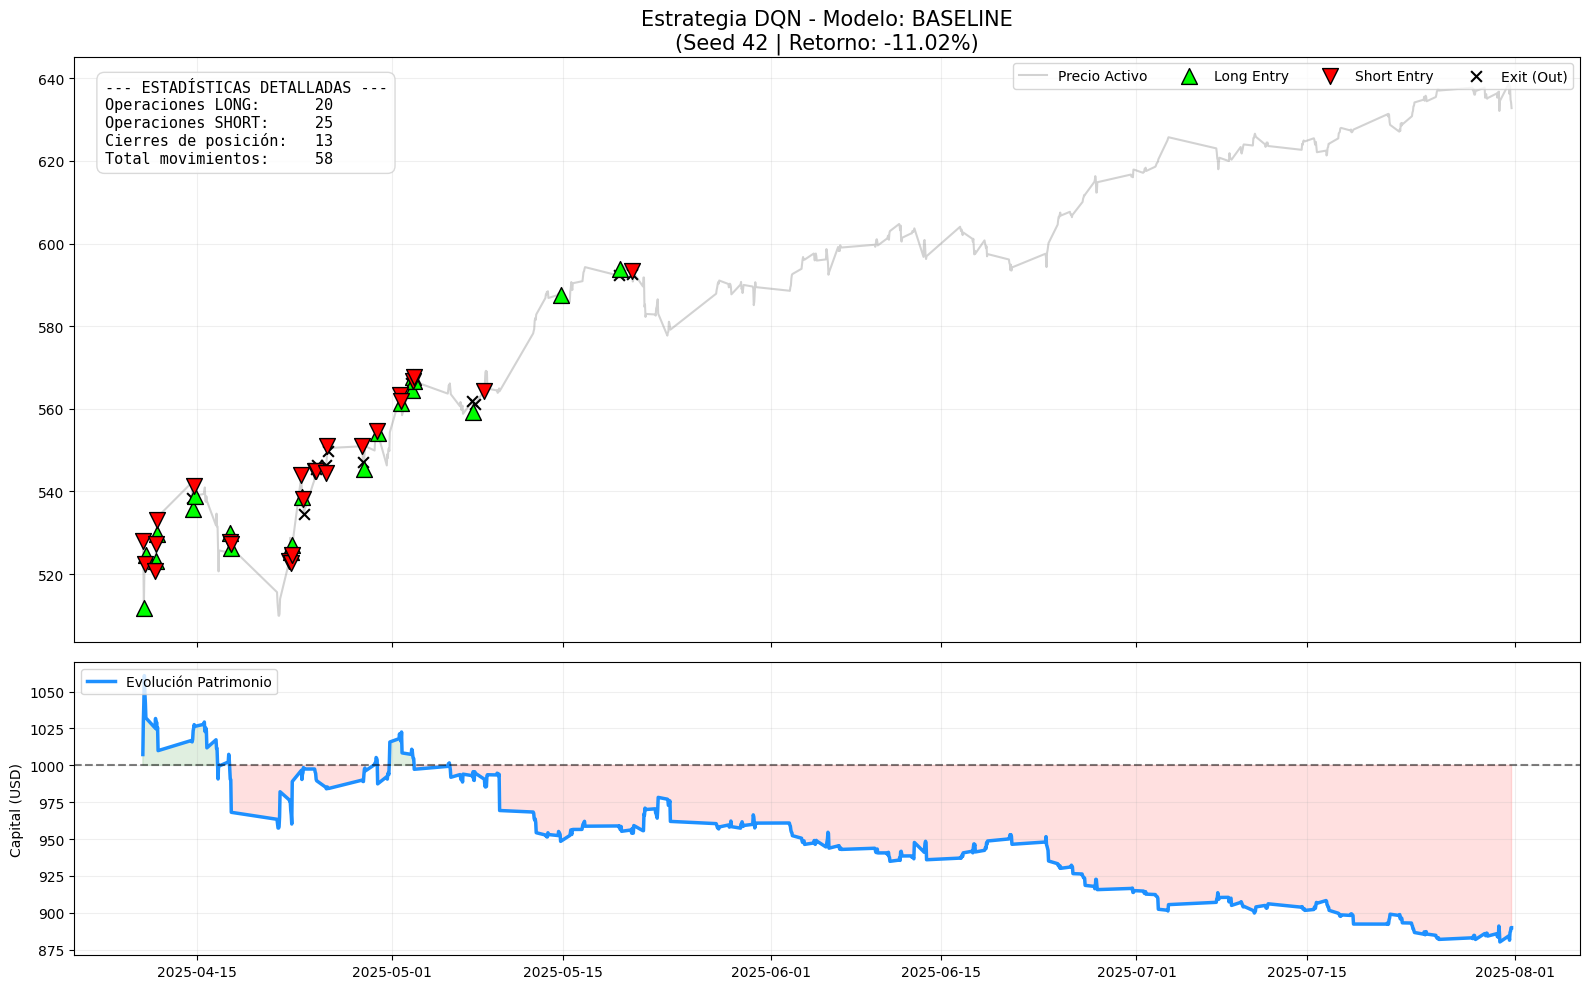


 📈 REPORTE VISUAL DQN: BASELINE | SEED: 123
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  16
📉 Operaciones SHORT: 35
✖️ Cierres de posición: 41
🔄 Total movimientos: 92
----------------------------------
💰 Capital Final: $812.20
📈 Retorno IA:      -18.78%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -38.60%


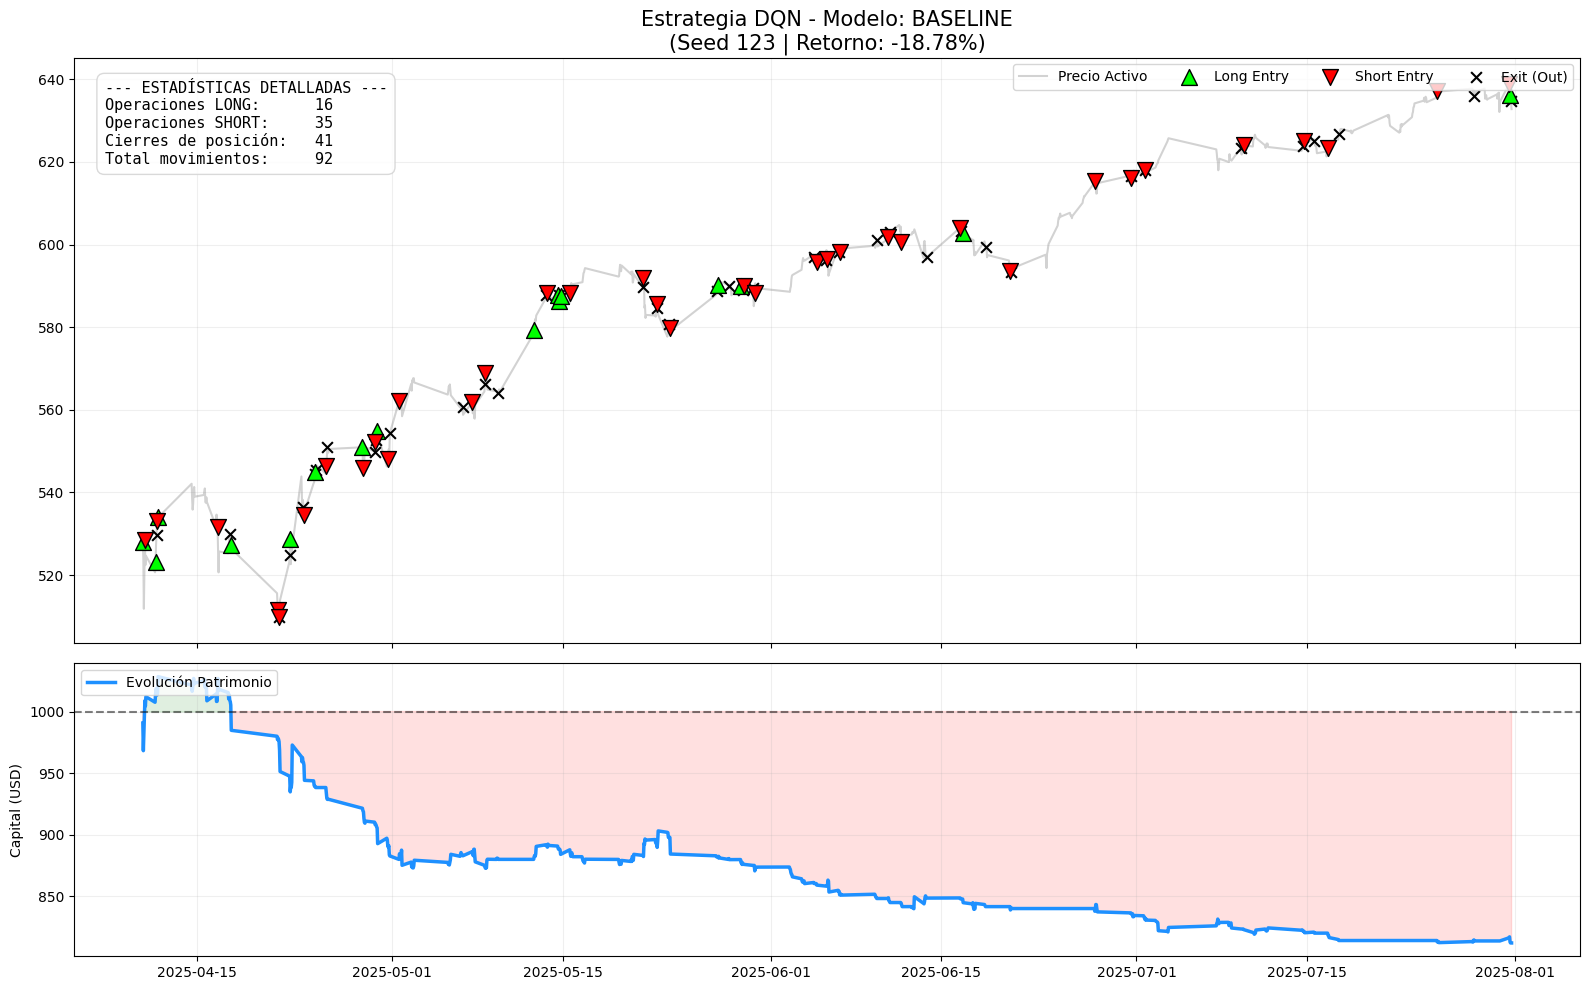


 📈 REPORTE VISUAL DQN: BASELINE | SEED: 456
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  27
📉 Operaciones SHORT: 28
✖️ Cierres de posición: 28
🔄 Total movimientos: 83
----------------------------------
💰 Capital Final: $872.85
📈 Retorno IA:      -12.71%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -32.53%


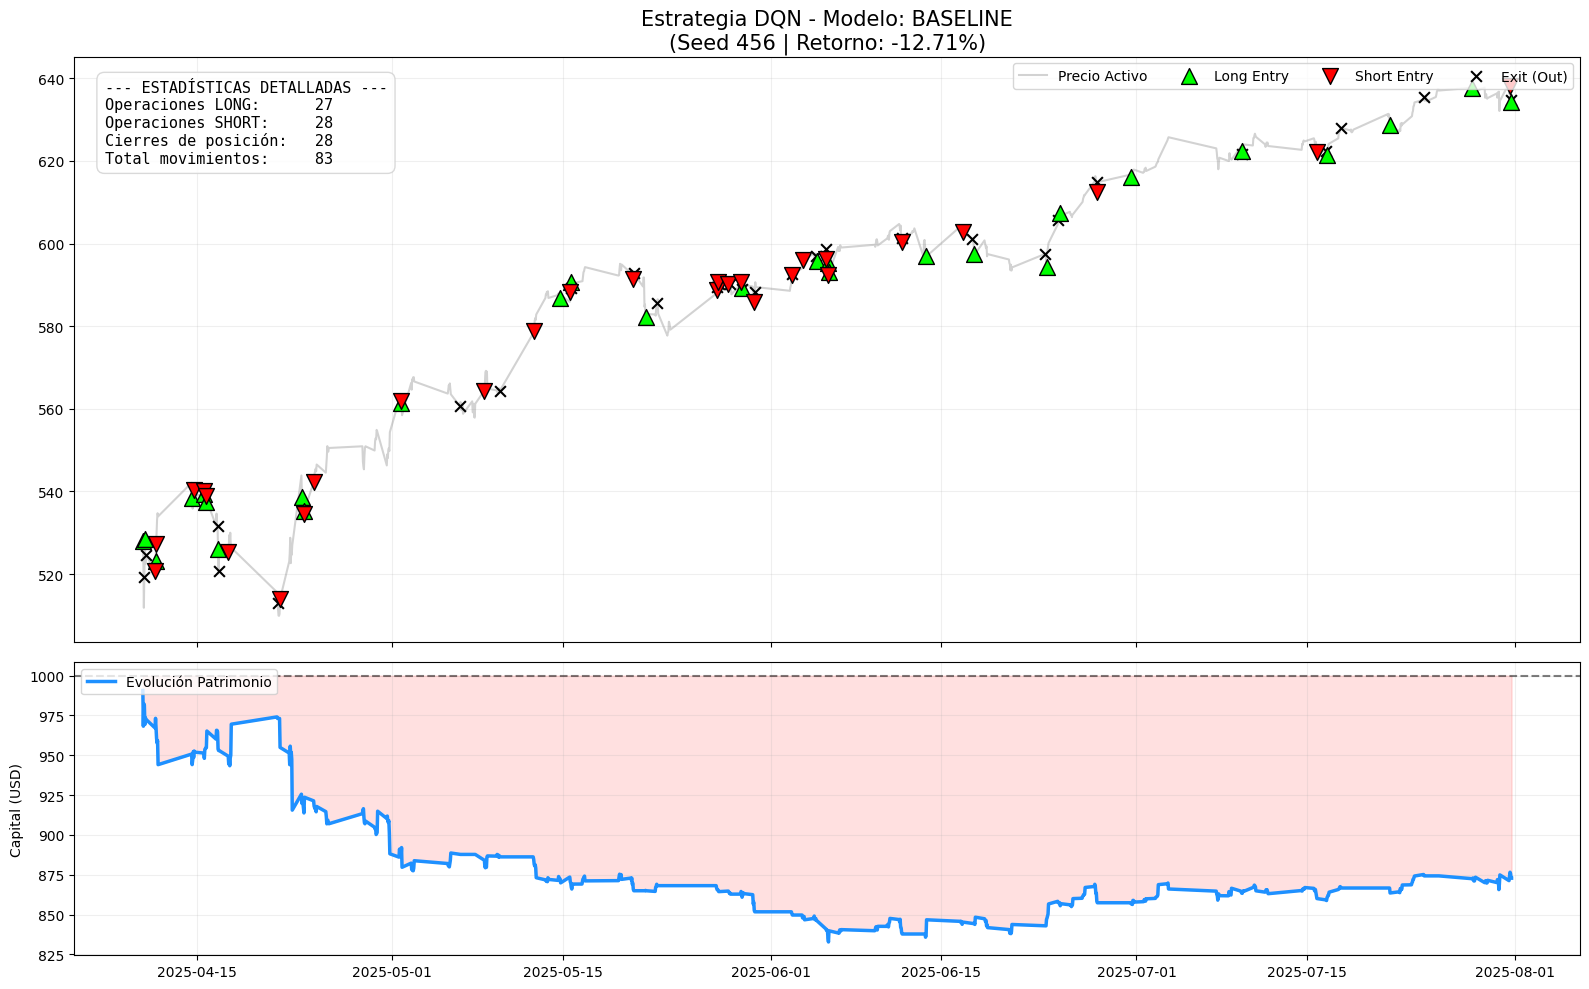


 📈 REPORTE VISUAL DQN: BASELINE | SEED: 789
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  20
📉 Operaciones SHORT: 11
✖️ Cierres de posición: 12
🔄 Total movimientos: 43
----------------------------------
💰 Capital Final: $986.05
📈 Retorno IA:      -1.39%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -21.21%


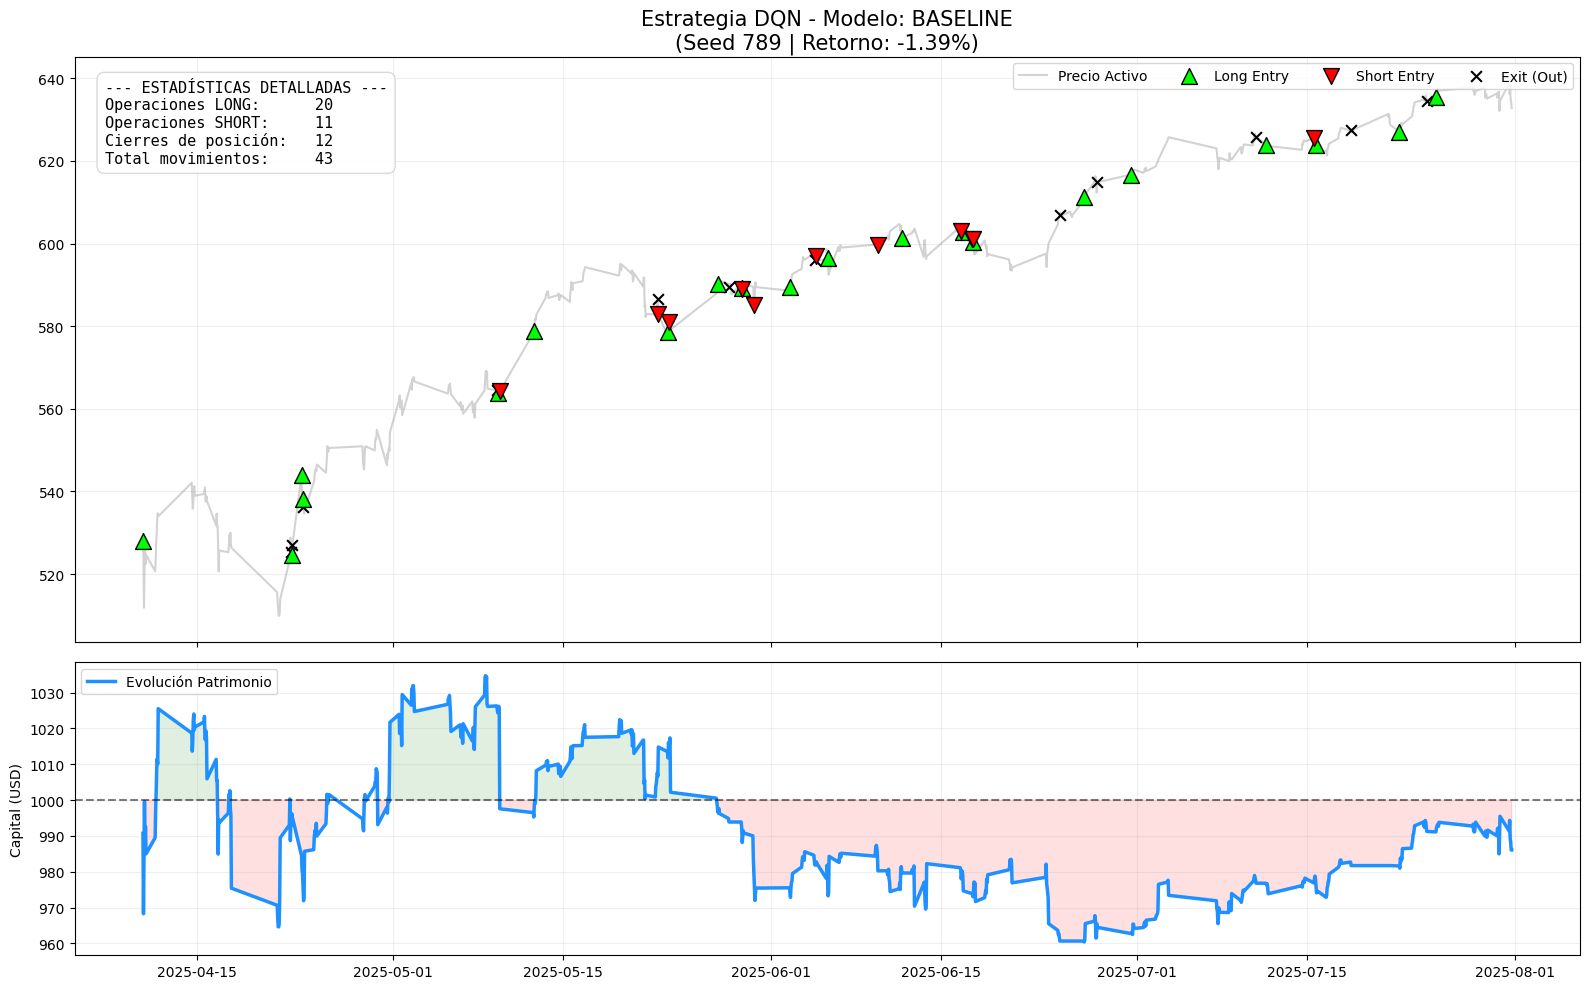


 📈 REPORTE VISUAL DQN: BASELINE | SEED: 1011
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  22
📉 Operaciones SHORT: 45
✖️ Cierres de posición: 35
🔄 Total movimientos: 102
----------------------------------
💰 Capital Final: $989.09
📈 Retorno IA:      -1.09%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -20.91%


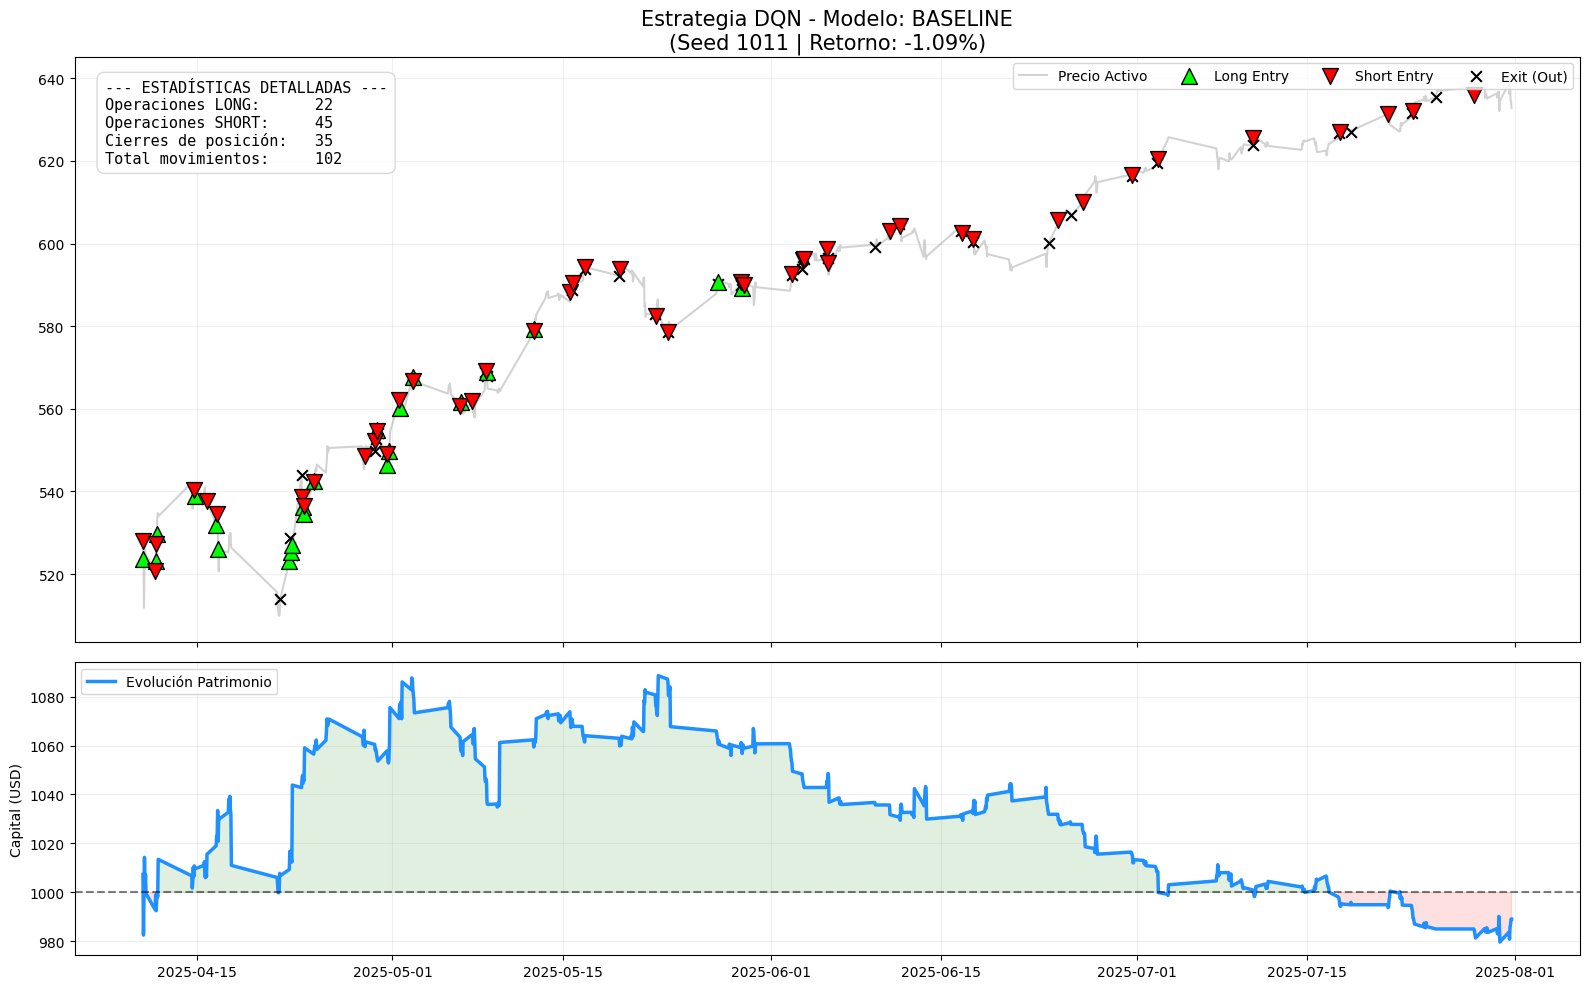


 📈 REPORTE VISUAL DQN: TEMPORAL-AE | SEED: 42
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  8
📉 Operaciones SHORT: 5
✖️ Cierres de posición: 10
🔄 Total movimientos: 23
----------------------------------
💰 Capital Final: $996.64
📈 Retorno IA:      -0.34%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -20.16%


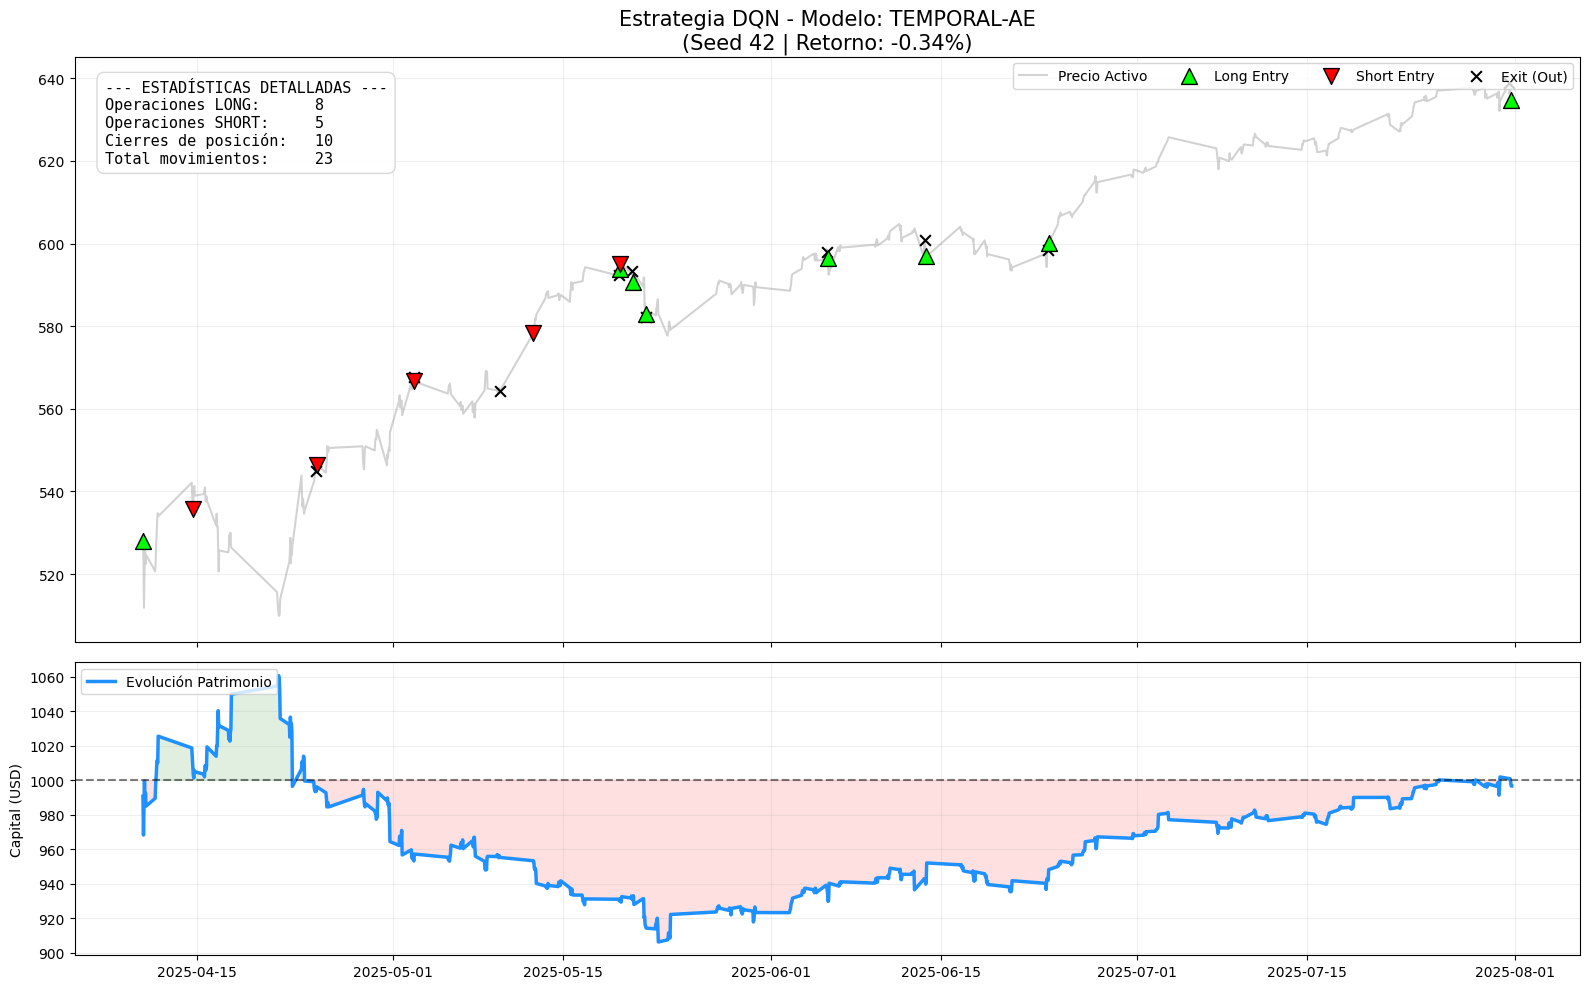


 📈 REPORTE VISUAL DQN: TEMPORAL-AE | SEED: 123
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  7
📉 Operaciones SHORT: 11
✖️ Cierres de posición: 10
🔄 Total movimientos: 28
----------------------------------
💰 Capital Final: $868.29
📈 Retorno IA:      -13.17%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -32.99%


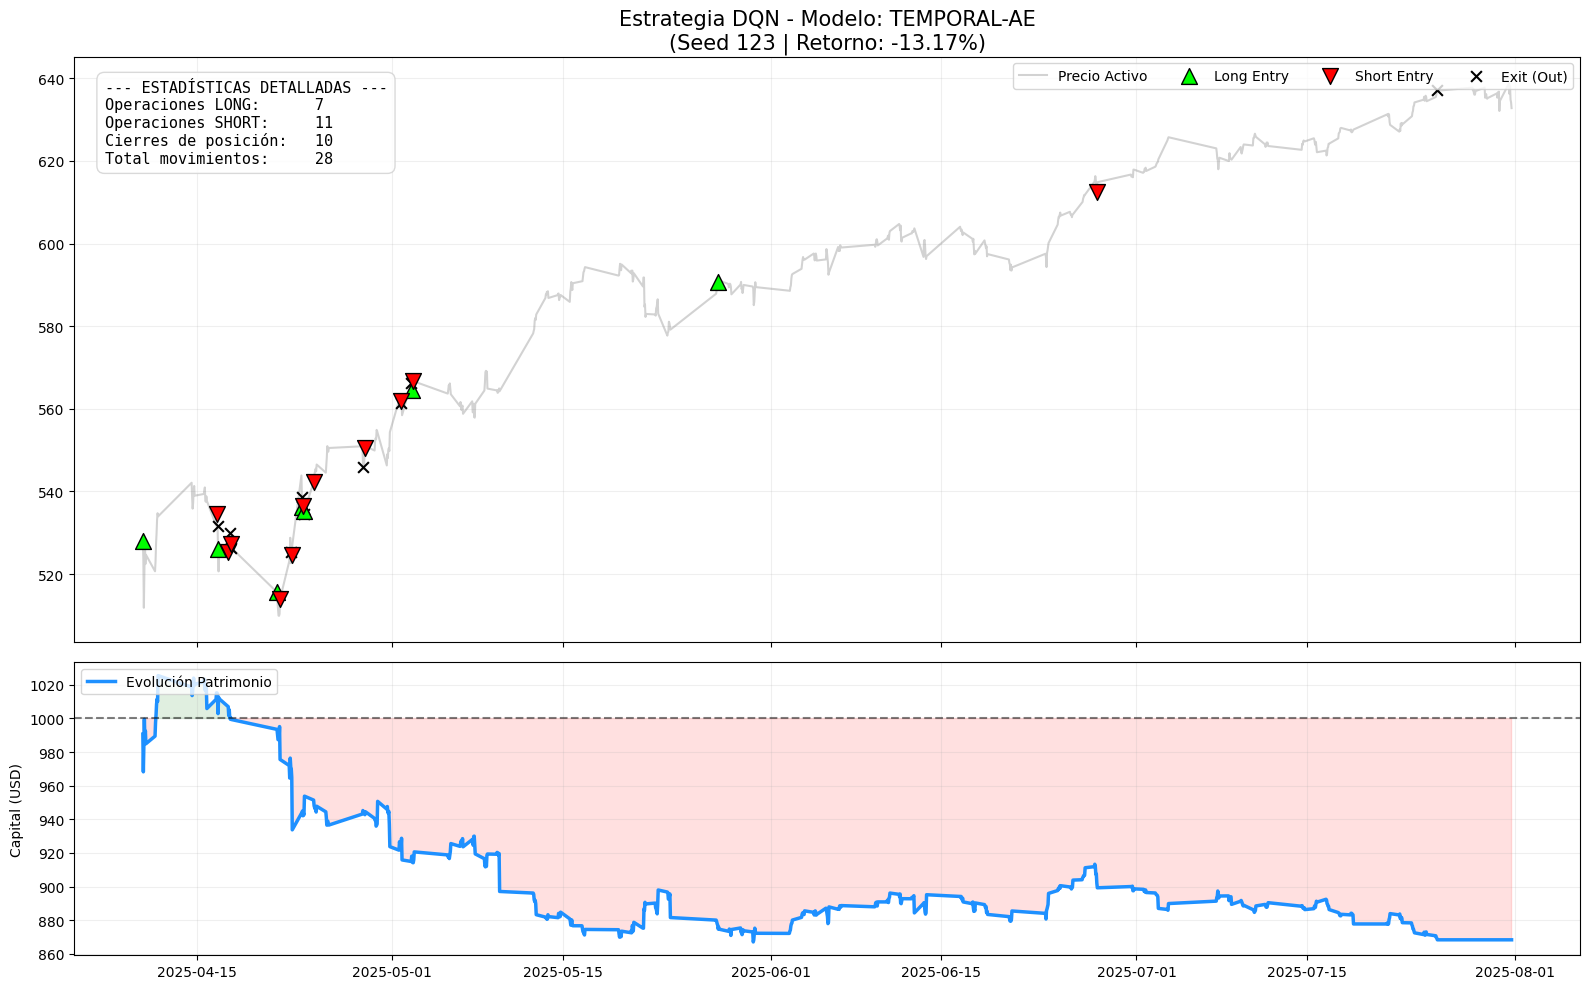


 📈 REPORTE VISUAL DQN: TEMPORAL-AE | SEED: 456
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  24
📉 Operaciones SHORT: 34
✖️ Cierres de posición: 27
🔄 Total movimientos: 85
----------------------------------
💰 Capital Final: $901.57
📈 Retorno IA:      -9.84%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -29.66%


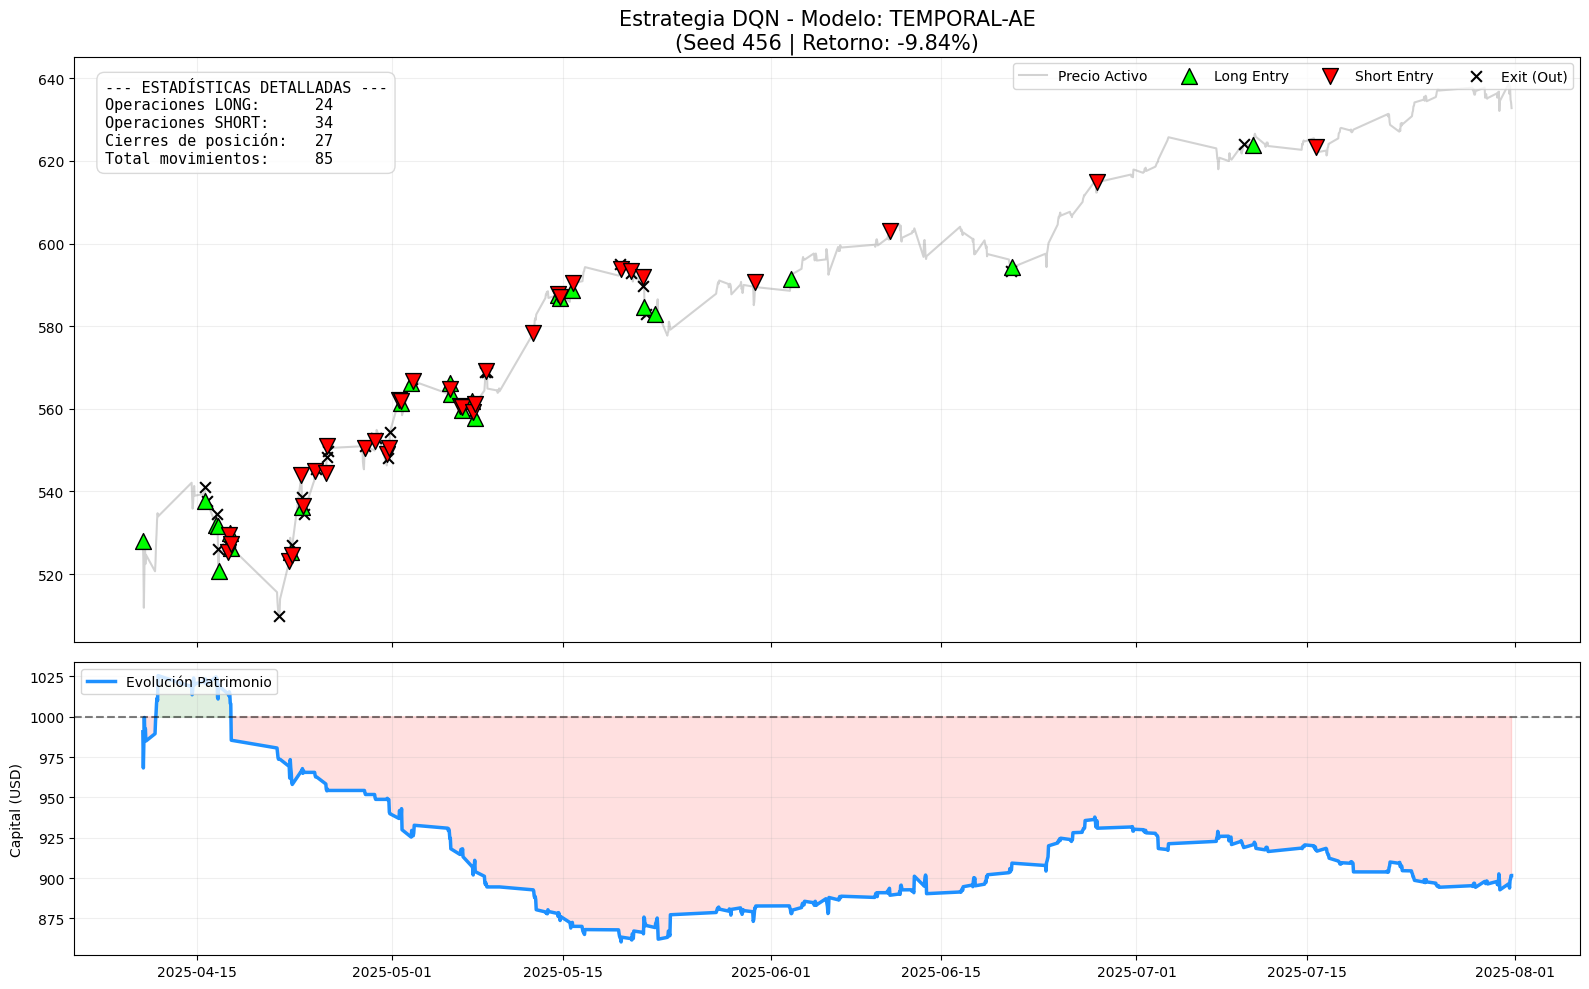


 📈 REPORTE VISUAL DQN: TEMPORAL-AE | SEED: 789
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  9
📉 Operaciones SHORT: 8
✖️ Cierres de posición: 4
🔄 Total movimientos: 21
----------------------------------
💰 Capital Final: $960.87
📈 Retorno IA:      -3.91%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -23.73%


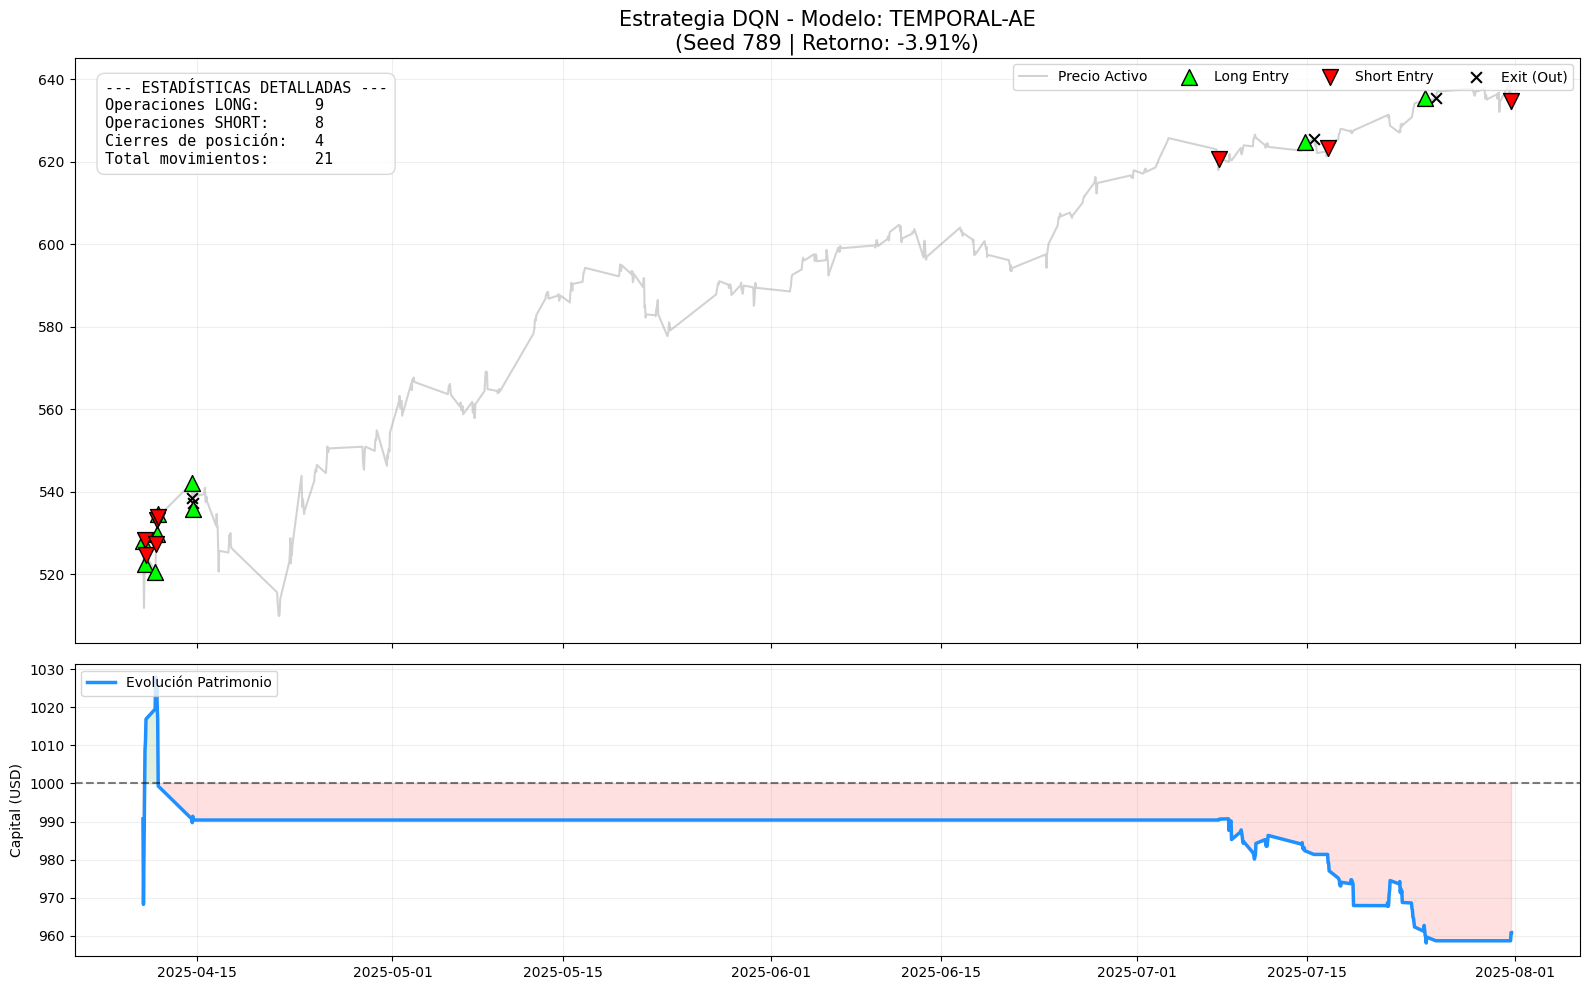


 📈 REPORTE VISUAL DQN: TEMPORAL-AE | SEED: 1011
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  4
📉 Operaciones SHORT: 4
✖️ Cierres de posición: 3
🔄 Total movimientos: 11
----------------------------------
💰 Capital Final: $1035.40
📈 Retorno IA:      3.54%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -16.28%


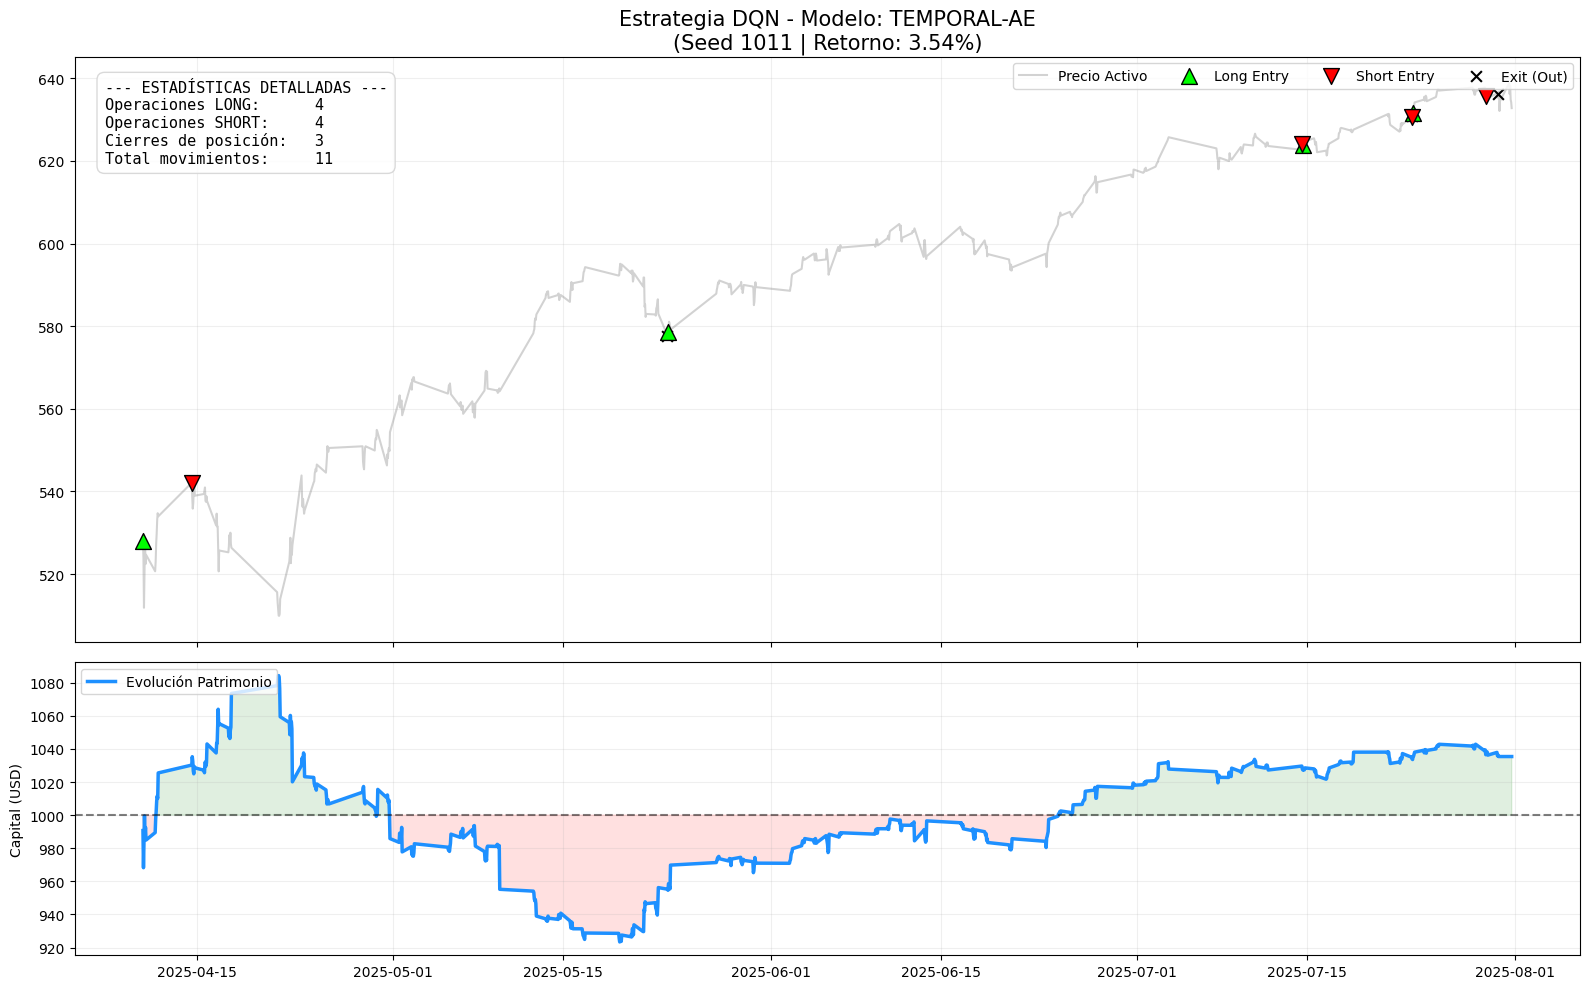


 📈 REPORTE VISUAL DQN: CPC | SEED: 42
✅ Datos sincronizados: 527 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  63
📉 Operaciones SHORT: 13
✖️ Cierres de posición: 69
🔄 Total movimientos: 145
----------------------------------
💰 Capital Final: $912.45
📈 Retorno IA:      -8.76%
📉 Retorno Mercado: 20.58%
🏆 Alpha vs Buy&Hold: -29.33%


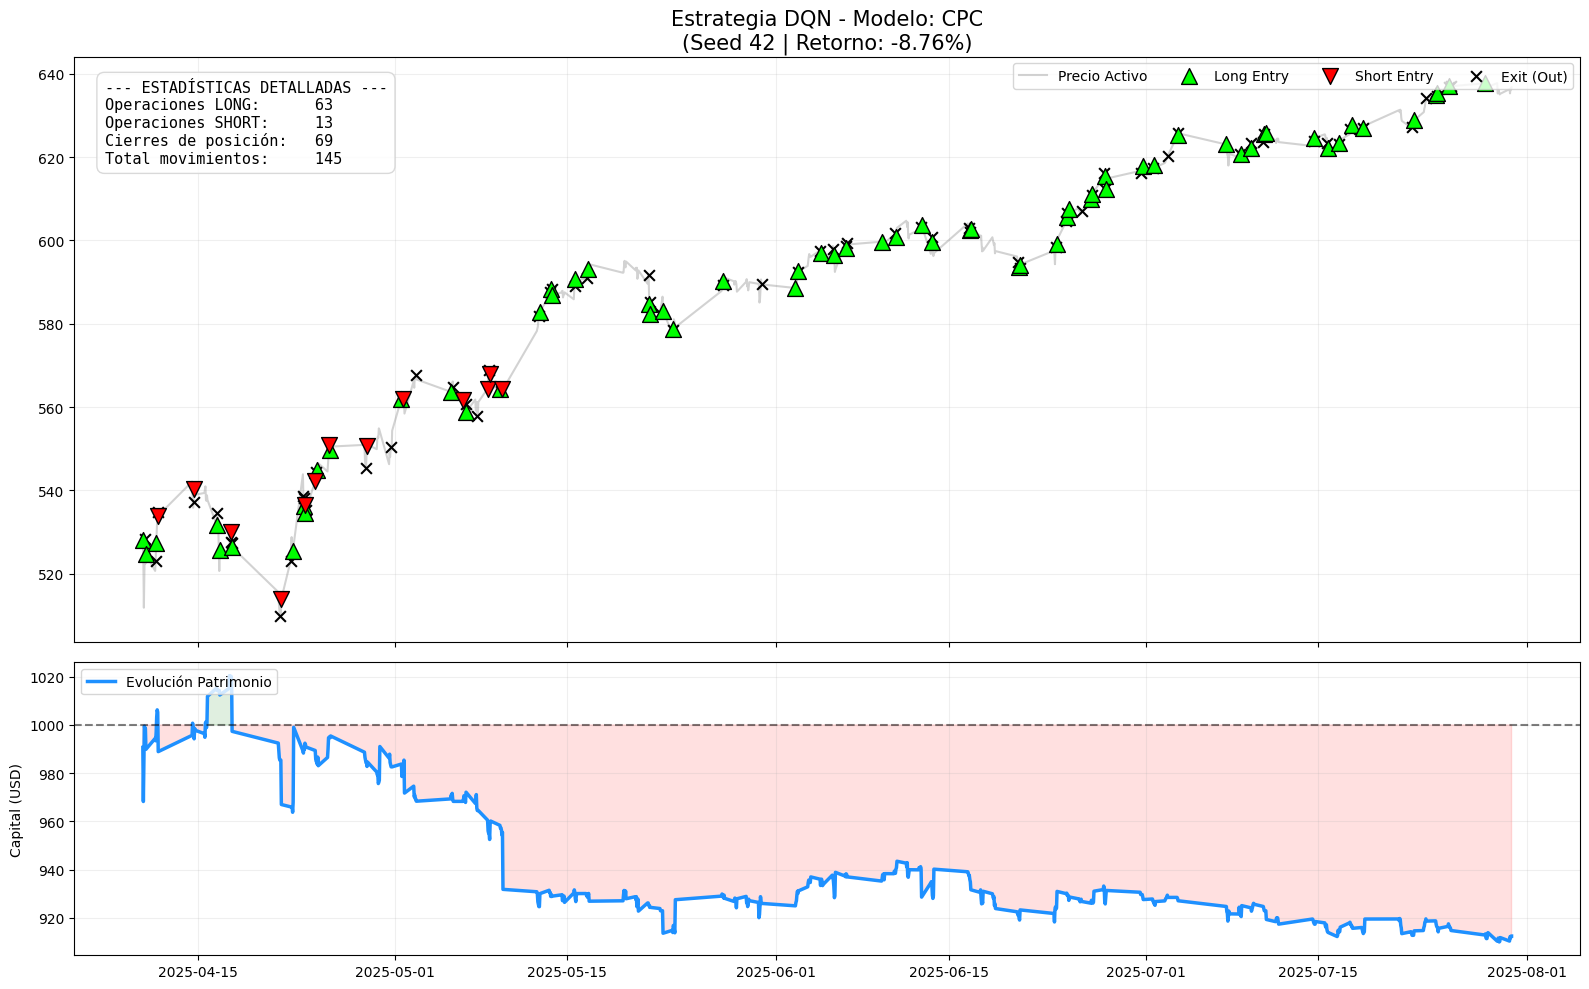


 📈 REPORTE VISUAL DQN: CPC | SEED: 123
✅ Datos sincronizados: 527 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  47
📉 Operaciones SHORT: 37
✖️ Cierres de posición: 57
🔄 Total movimientos: 141
----------------------------------
💰 Capital Final: $951.82
📈 Retorno IA:      -4.82%
📉 Retorno Mercado: 20.58%
🏆 Alpha vs Buy&Hold: -25.39%


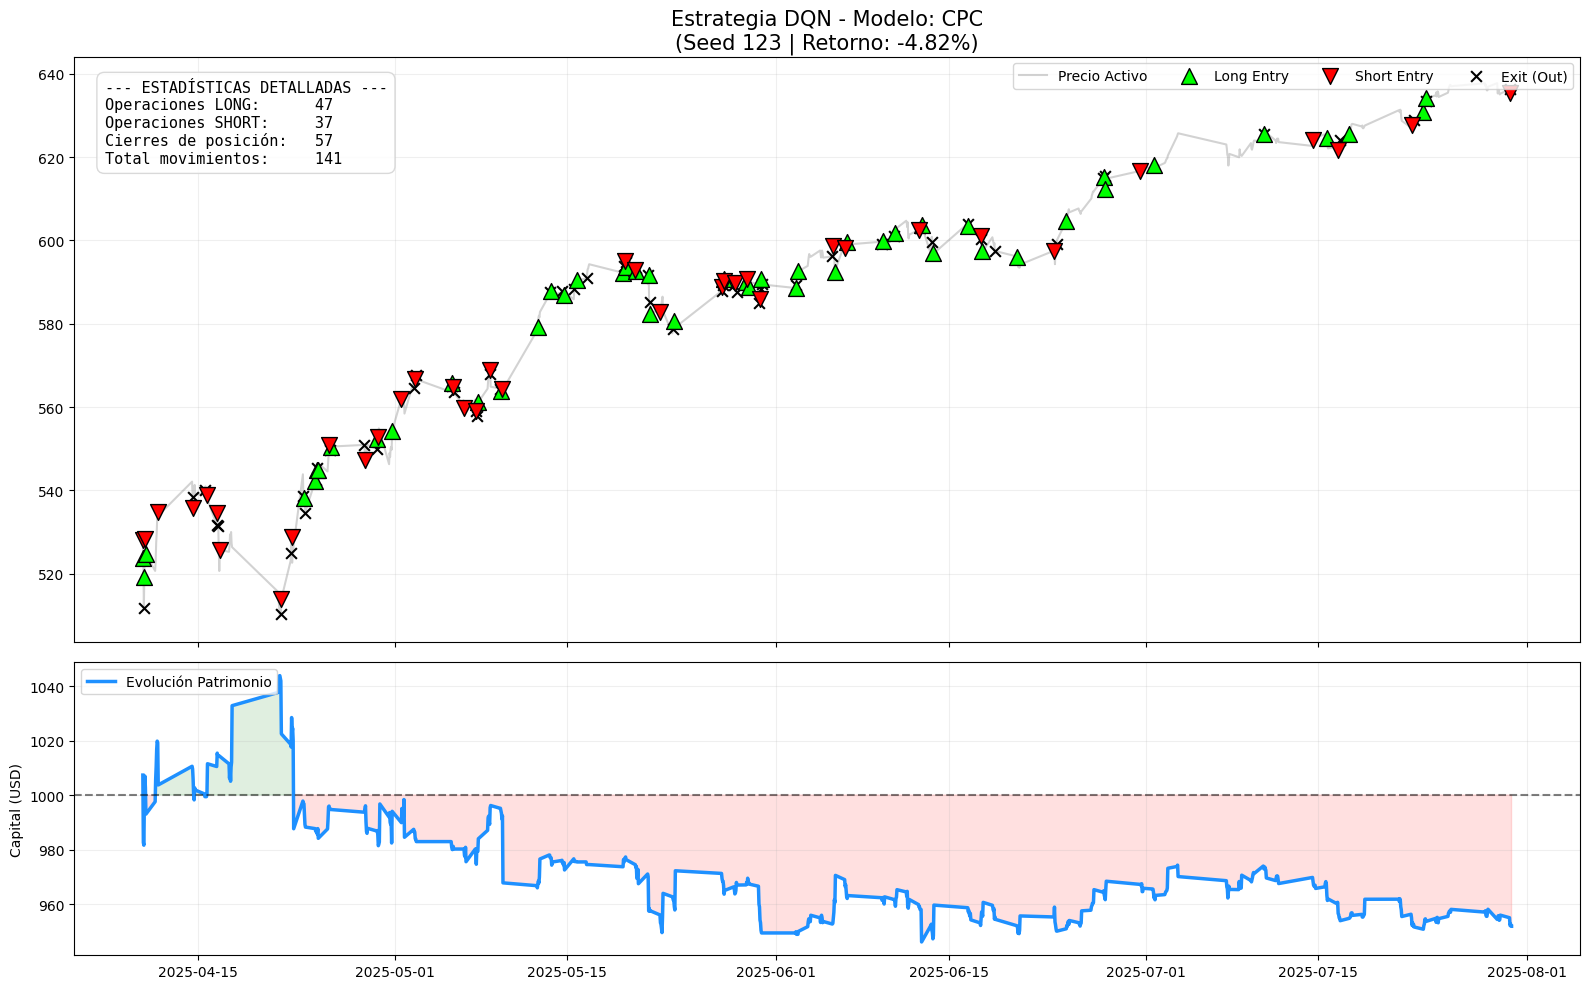


 📈 REPORTE VISUAL DQN: CPC | SEED: 456
✅ Datos sincronizados: 527 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  68
📉 Operaciones SHORT: 67
✖️ Cierres de posición: 84
🔄 Total movimientos: 219
----------------------------------
💰 Capital Final: $730.65
📈 Retorno IA:      -26.94%
📉 Retorno Mercado: 20.58%
🏆 Alpha vs Buy&Hold: -47.51%


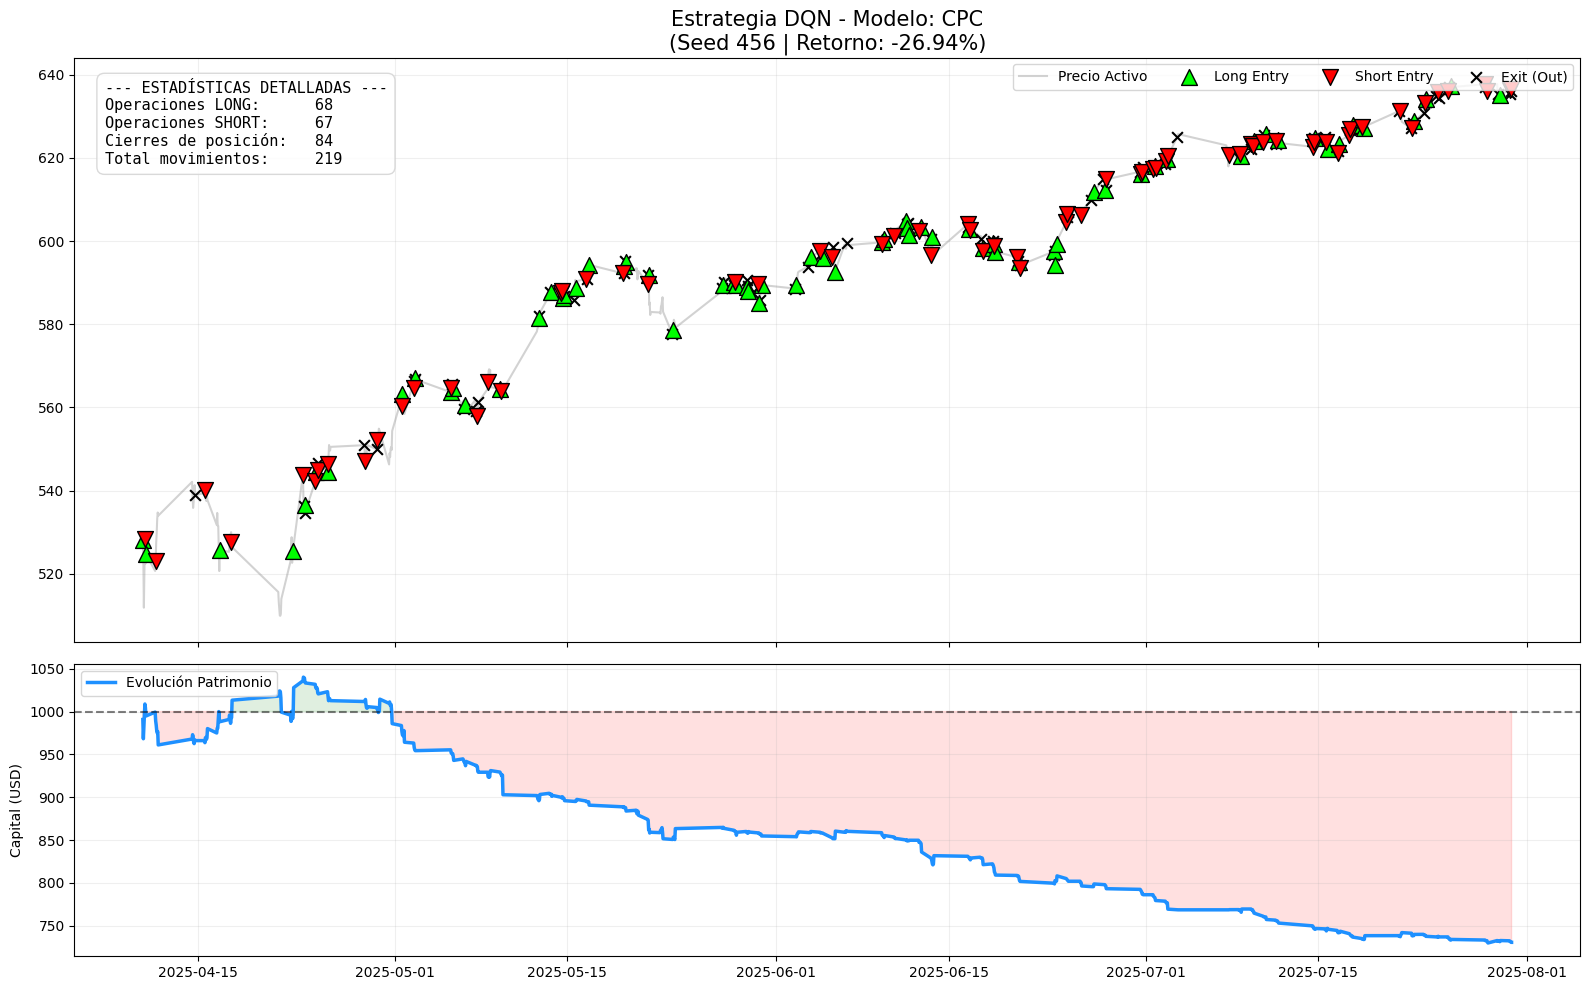


 📈 REPORTE VISUAL DQN: CPC | SEED: 789
✅ Datos sincronizados: 527 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  58
📉 Operaciones SHORT: 25
✖️ Cierres de posición: 60
🔄 Total movimientos: 143
----------------------------------
💰 Capital Final: $849.20
📈 Retorno IA:      -15.08%
📉 Retorno Mercado: 20.58%
🏆 Alpha vs Buy&Hold: -35.66%


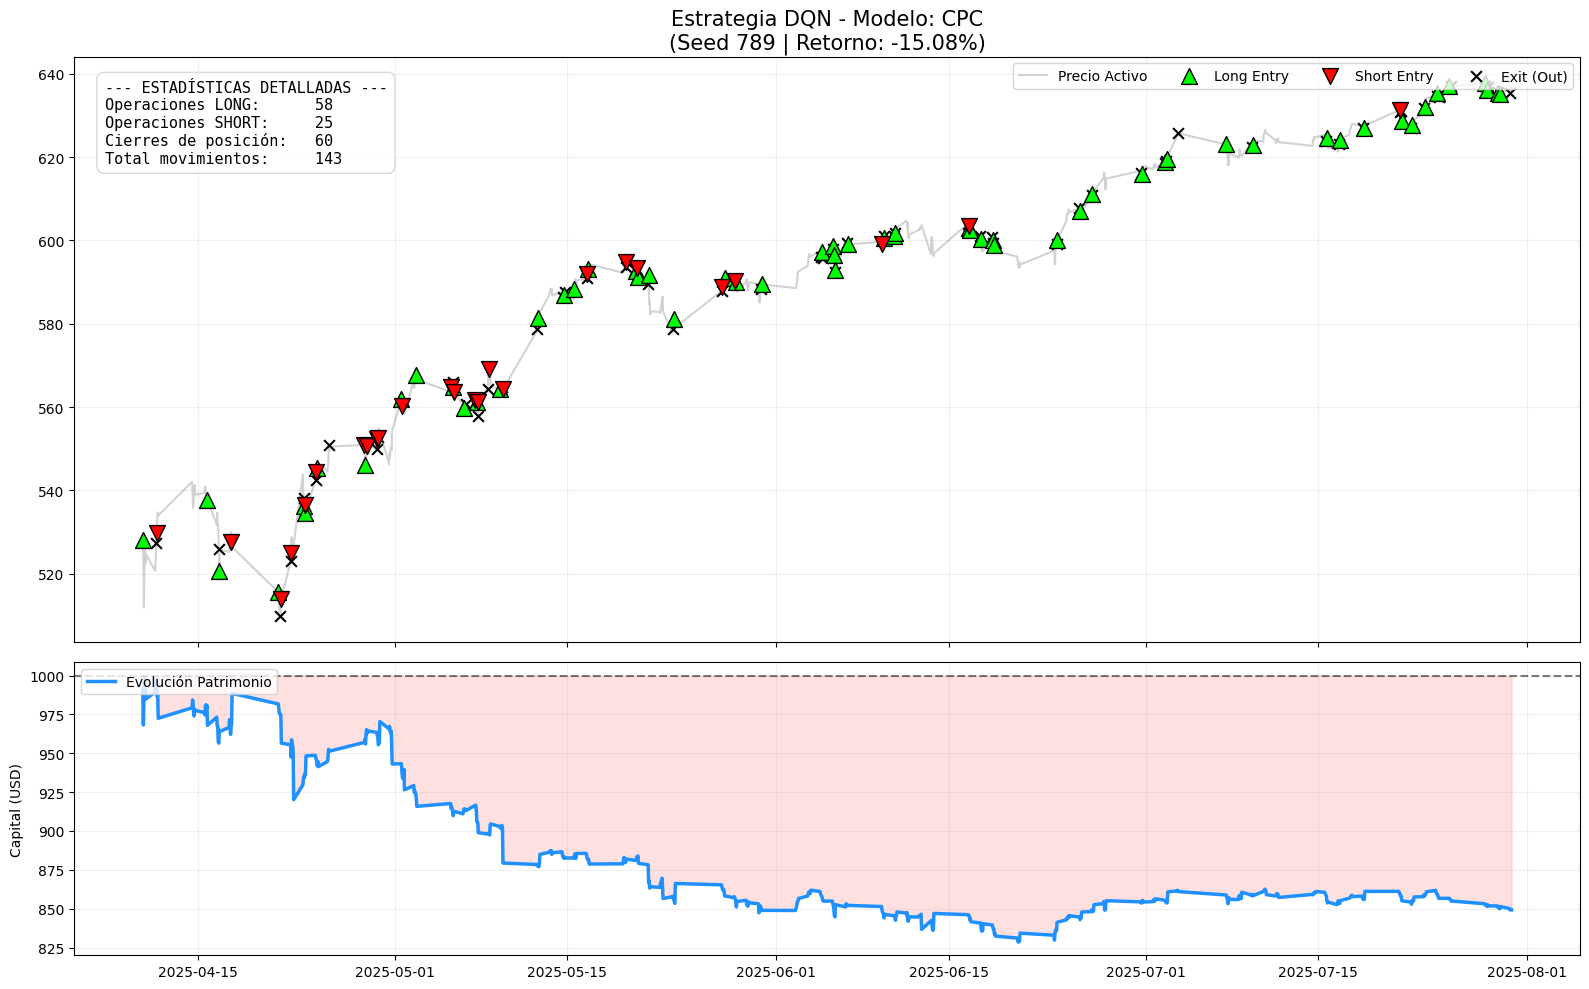


 📈 REPORTE VISUAL DQN: CPC | SEED: 1011
✅ Datos sincronizados: 527 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  54
📉 Operaciones SHORT: 56
✖️ Cierres de posición: 24
🔄 Total movimientos: 134
----------------------------------
💰 Capital Final: $855.07
📈 Retorno IA:      -14.49%
📉 Retorno Mercado: 20.58%
🏆 Alpha vs Buy&Hold: -35.07%


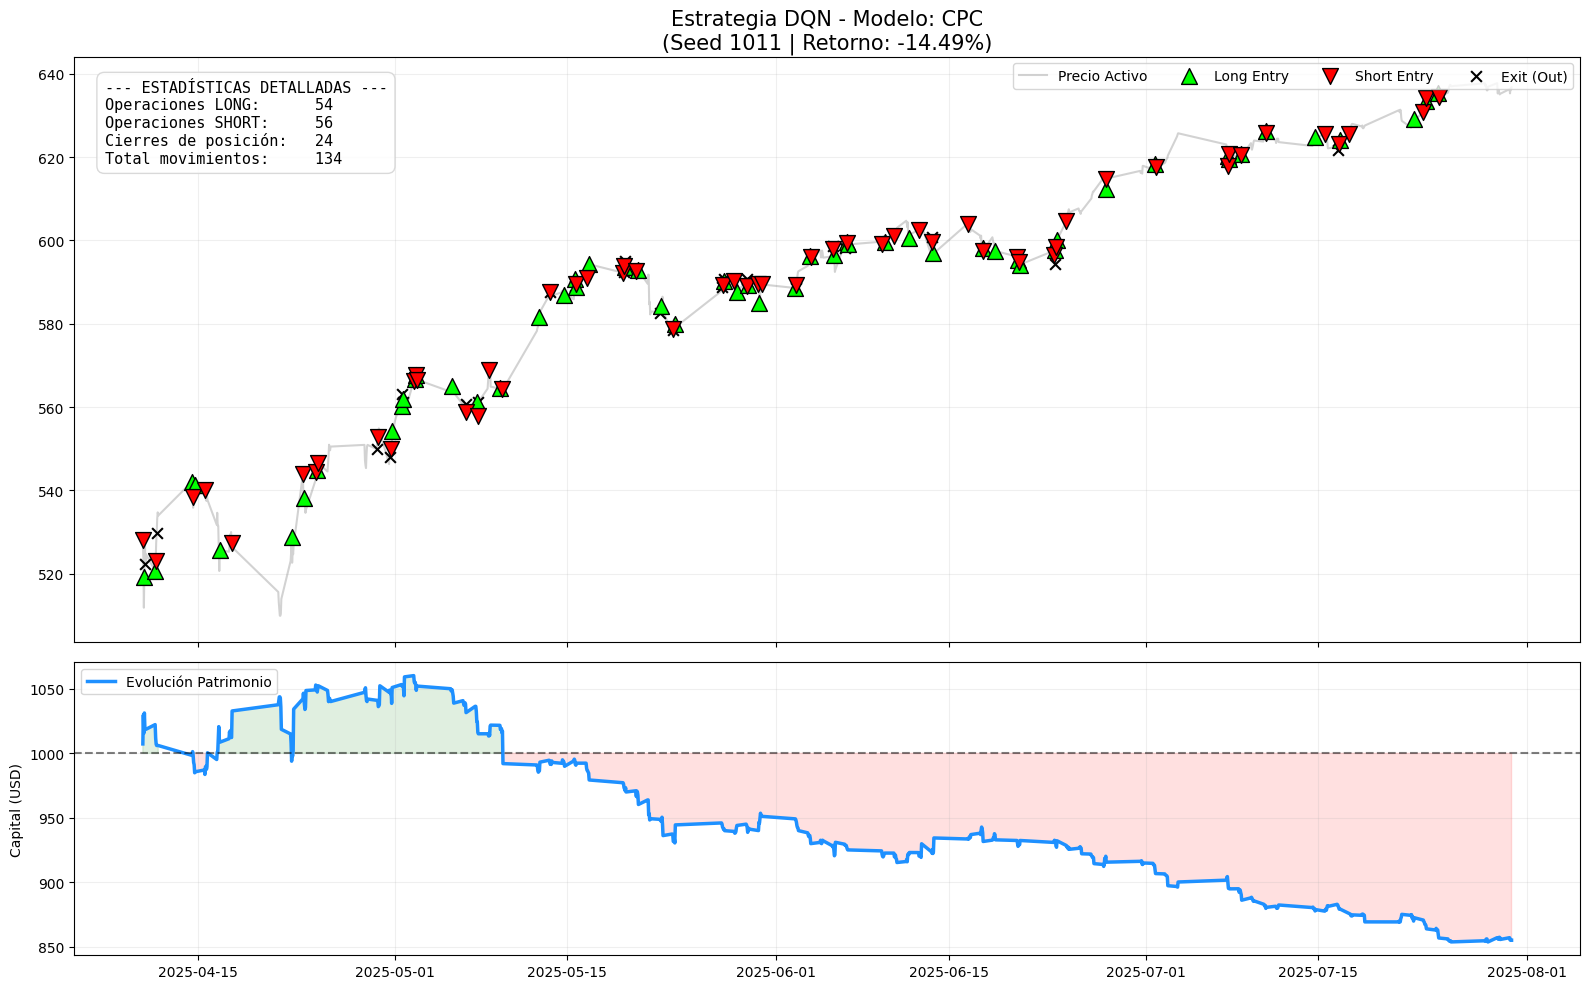


 📈 REPORTE VISUAL DQN: TRANSFORMER | SEED: 42
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  9
📉 Operaciones SHORT: 11
✖️ Cierres de posición: 6
🔄 Total movimientos: 26
----------------------------------
💰 Capital Final: $1116.46
📈 Retorno IA:      11.65%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -8.17%


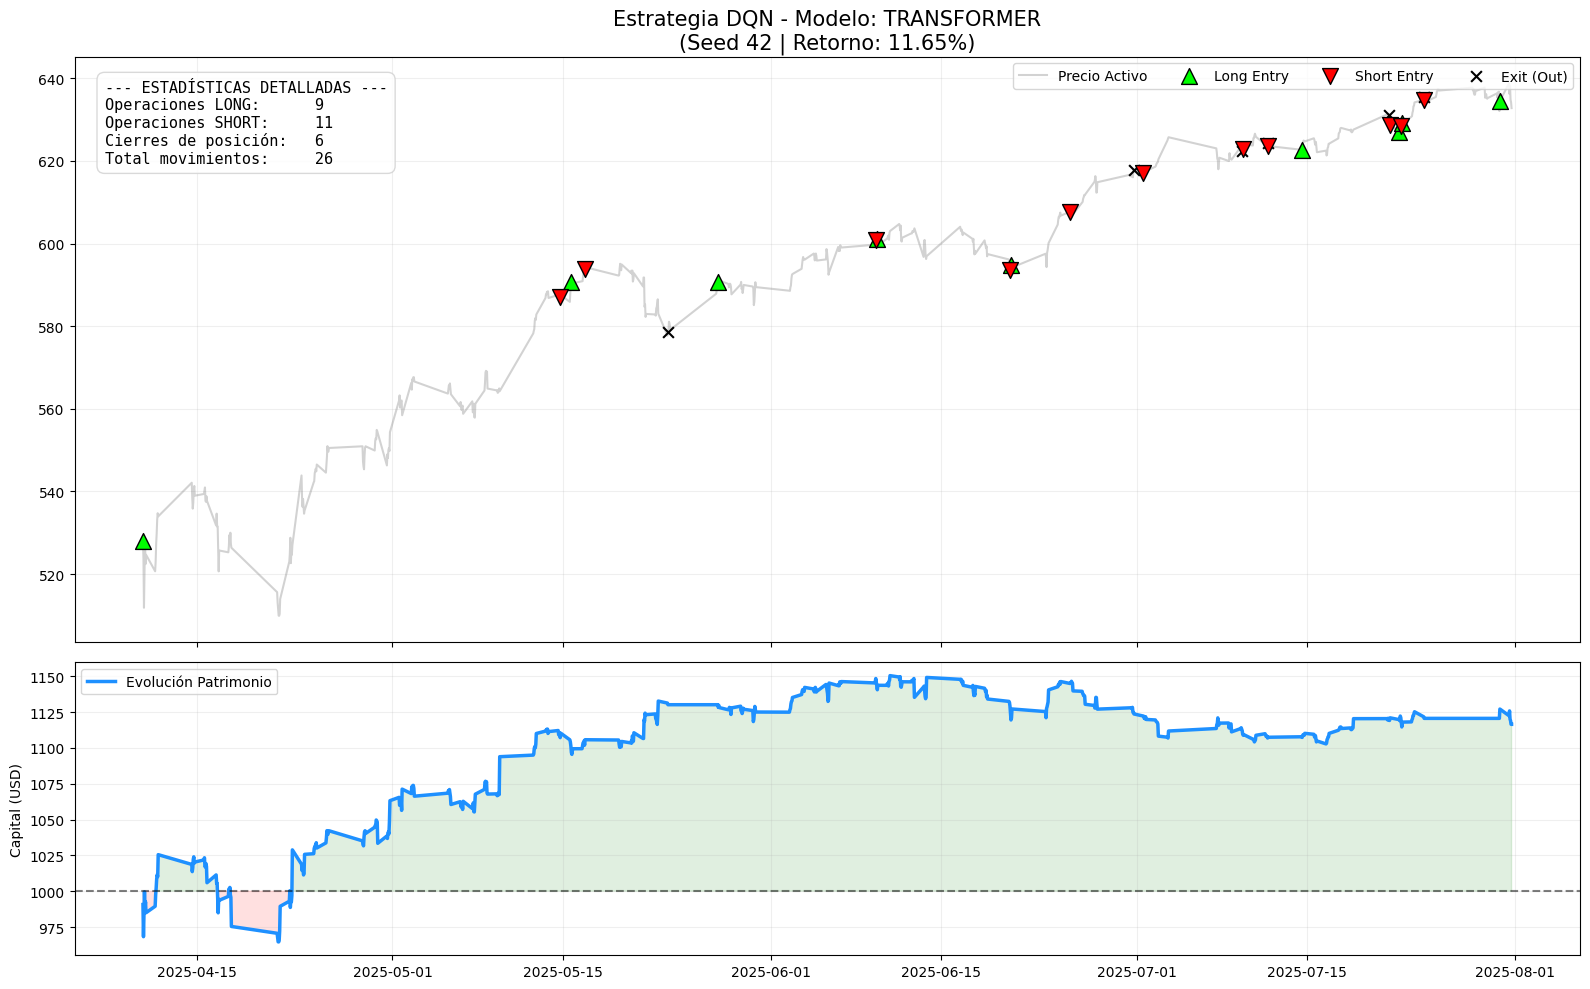


 📈 REPORTE VISUAL DQN: TRANSFORMER | SEED: 123
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  5
📉 Operaciones SHORT: 5
✖️ Cierres de posición: 5
🔄 Total movimientos: 15
----------------------------------
💰 Capital Final: $1020.84
📈 Retorno IA:      2.08%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -17.74%


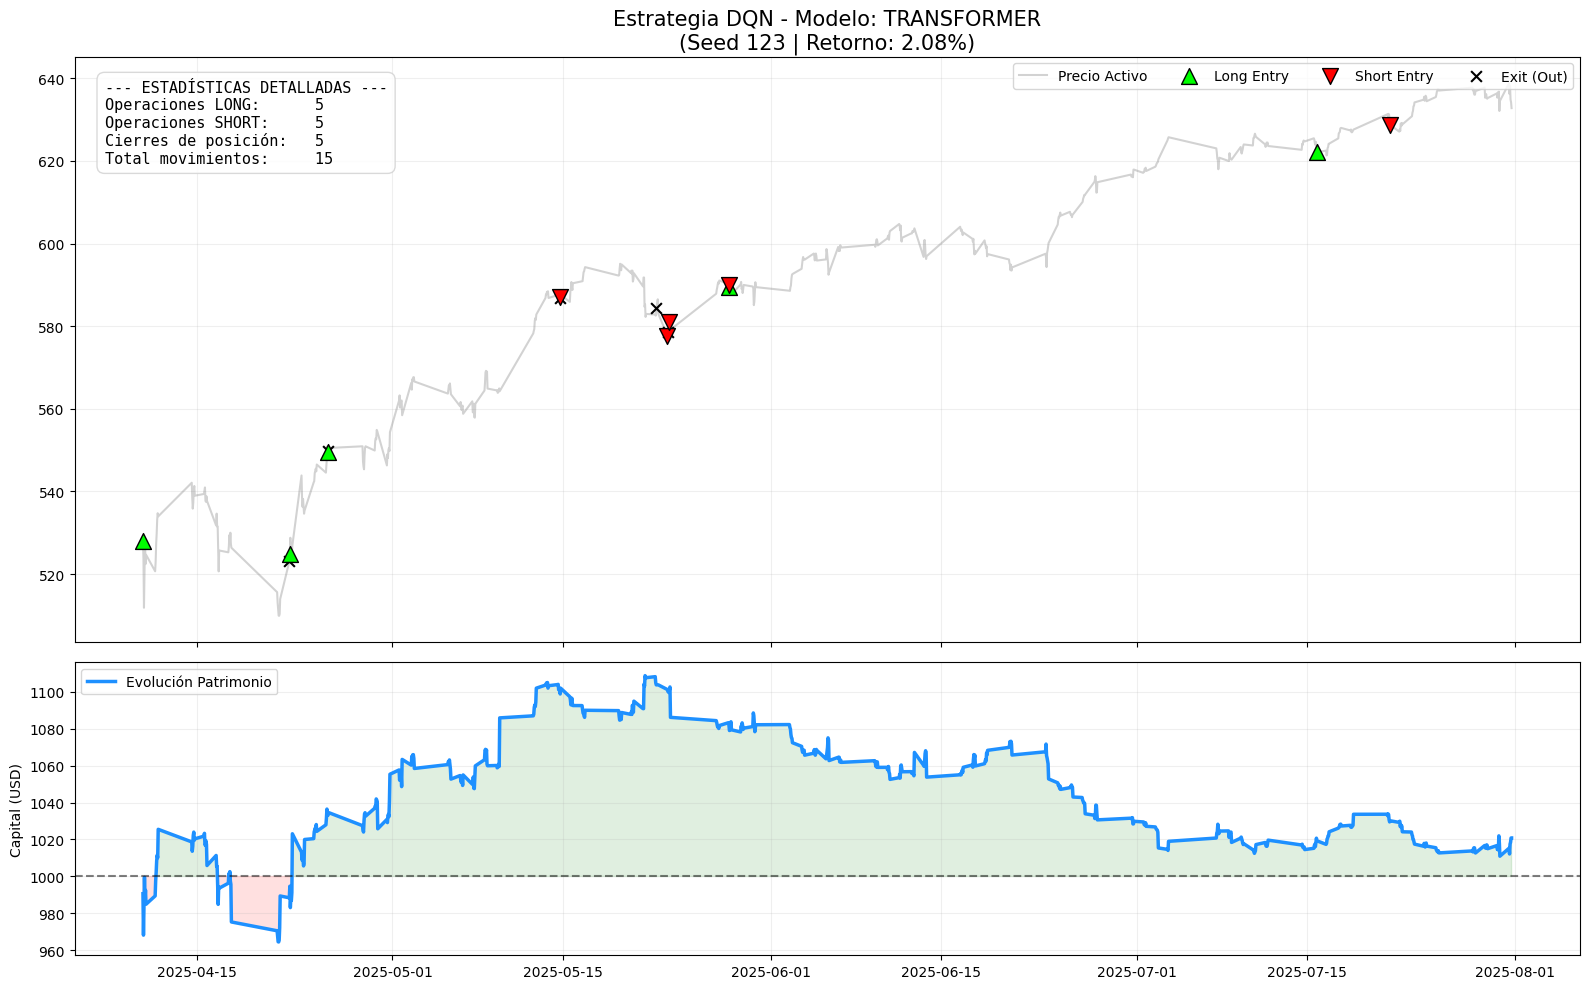


 📈 REPORTE VISUAL DQN: TRANSFORMER | SEED: 456
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  24
📉 Operaciones SHORT: 18
✖️ Cierres de posición: 6
🔄 Total movimientos: 48
----------------------------------
💰 Capital Final: $1023.96
📈 Retorno IA:      2.40%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -17.42%


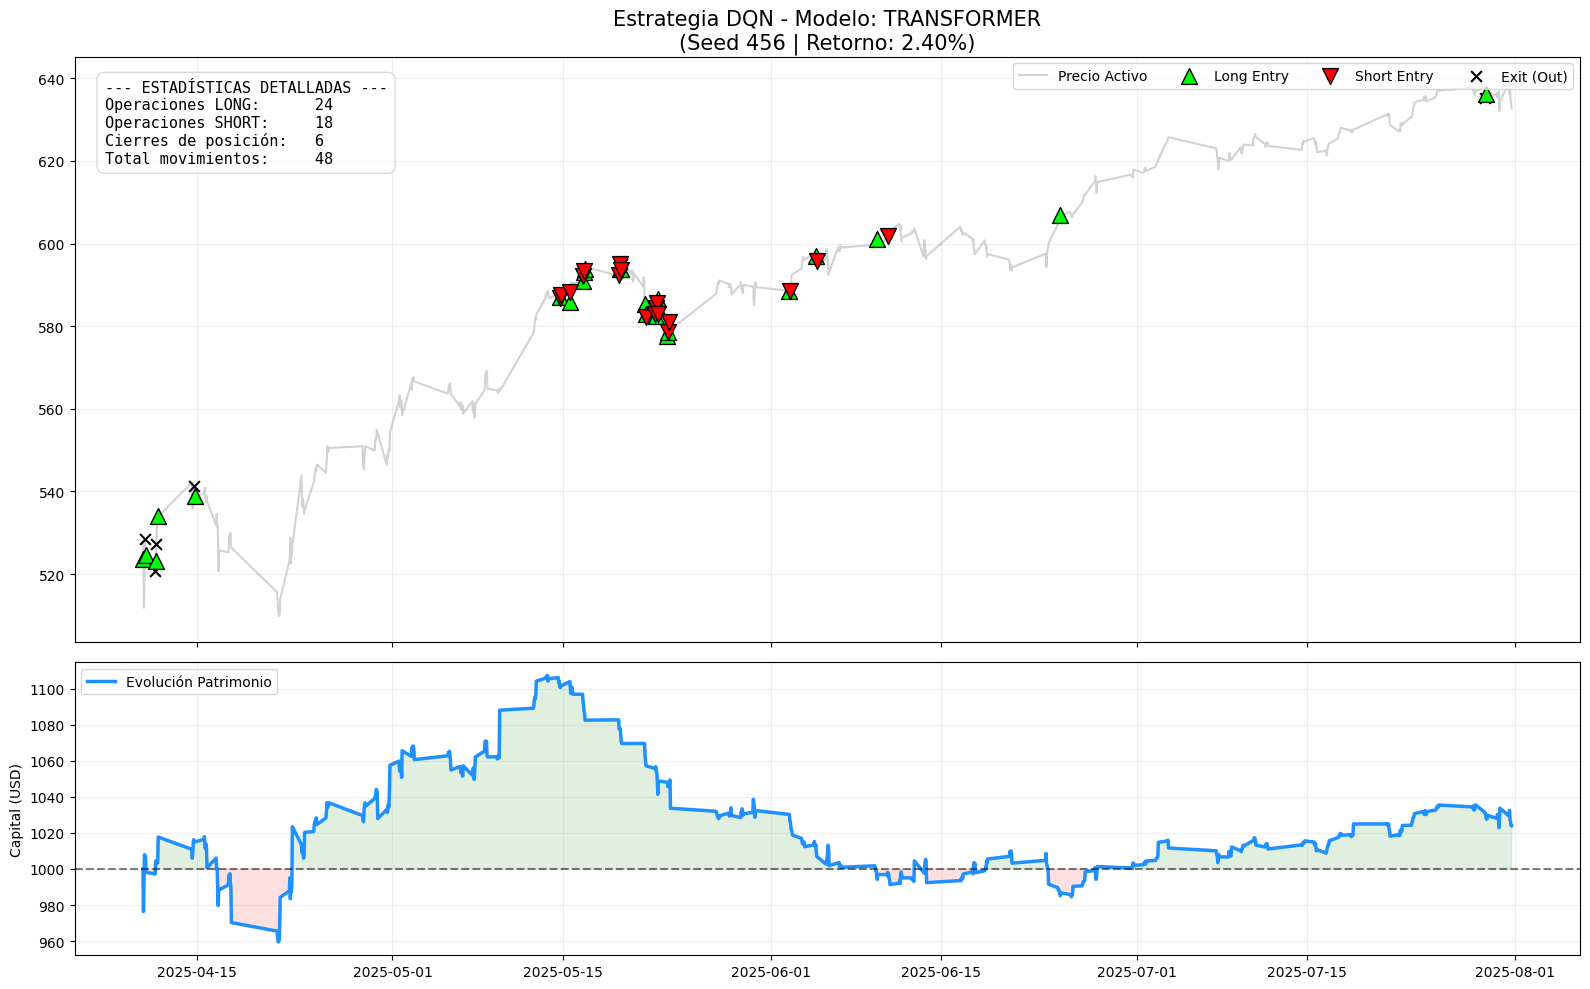


 📈 REPORTE VISUAL DQN: TRANSFORMER | SEED: 789
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  16
📉 Operaciones SHORT: 1
✖️ Cierres de posición: 15
🔄 Total movimientos: 32
----------------------------------
💰 Capital Final: $1110.62
📈 Retorno IA:      11.06%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -8.76%


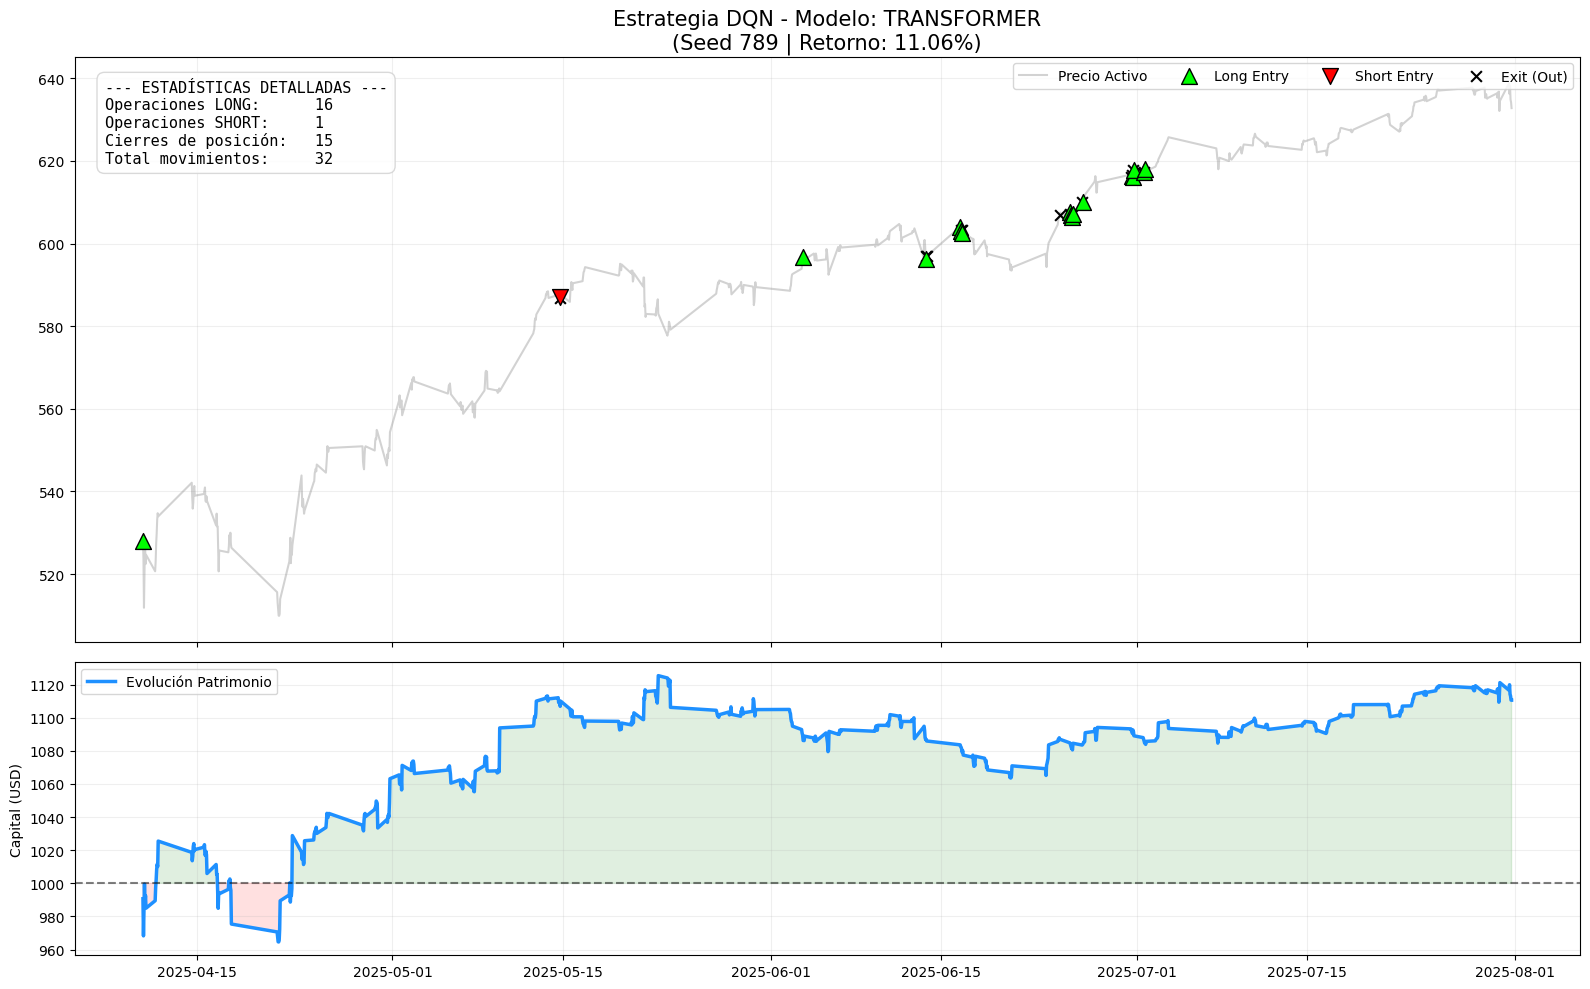


 📈 REPORTE VISUAL DQN: TRANSFORMER | SEED: 1011
✅ Datos sincronizados: 535 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  101
📉 Operaciones SHORT: 53
✖️ Cierres de posición: 48
🔄 Total movimientos: 202
----------------------------------
💰 Capital Final: $726.80
📈 Retorno IA:      -27.32%
📉 Retorno Mercado: 19.82%
🏆 Alpha vs Buy&Hold: -47.14%


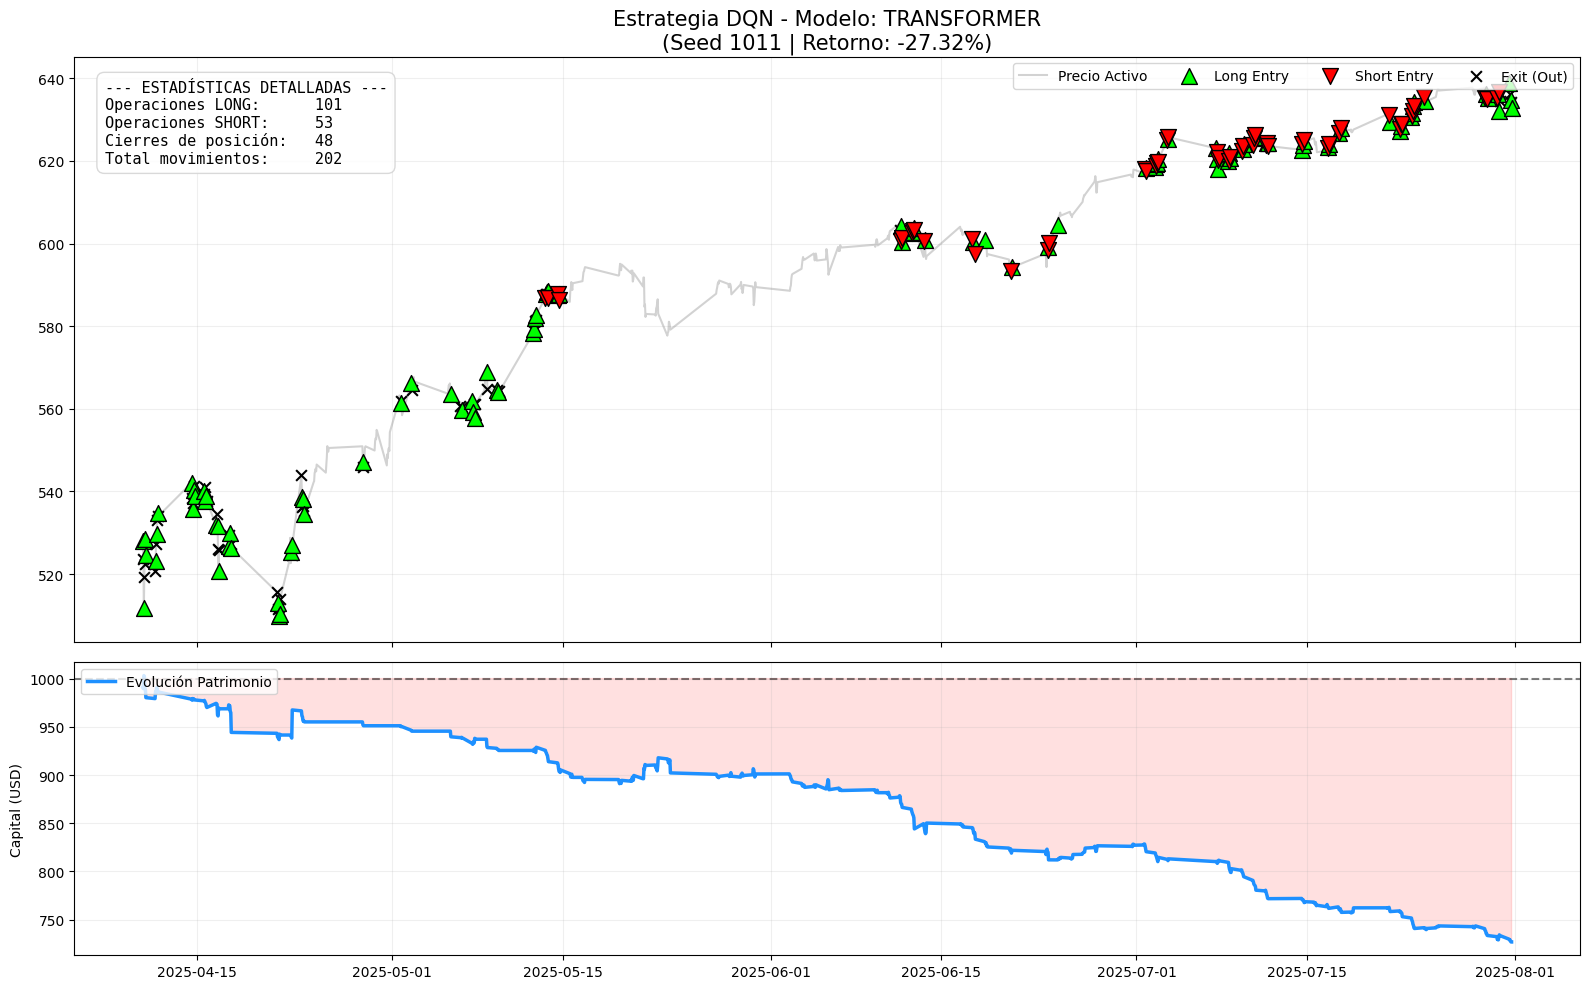


 📈 REPORTE VISUAL DQN: COMBINADO | SEED: 42
✅ Datos sincronizados: 527 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  48
📉 Operaciones SHORT: 26
✖️ Cierres de posición: 55
🔄 Total movimientos: 129
----------------------------------
💰 Capital Final: $971.27
📈 Retorno IA:      -2.87%
📉 Retorno Mercado: 20.58%
🏆 Alpha vs Buy&Hold: -23.45%


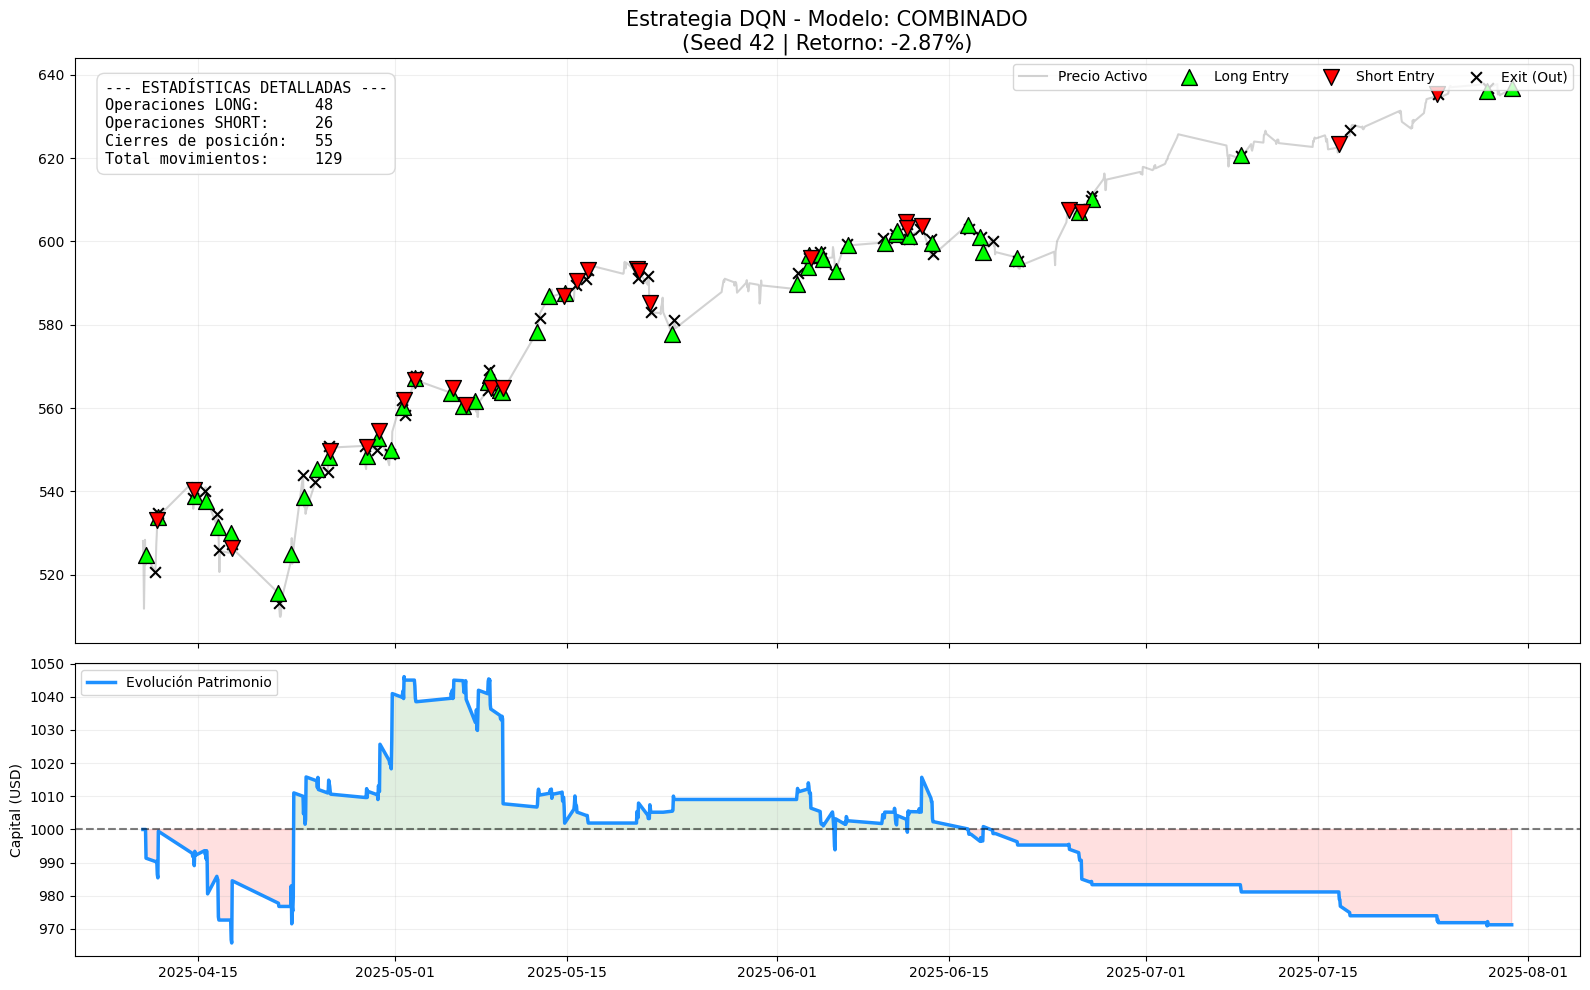


 📈 REPORTE VISUAL DQN: COMBINADO | SEED: 123
✅ Datos sincronizados: 527 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  48
📉 Operaciones SHORT: 26
✖️ Cierres de posición: 55
🔄 Total movimientos: 129
----------------------------------
💰 Capital Final: $862.88
📈 Retorno IA:      -13.71%
📉 Retorno Mercado: 20.58%
🏆 Alpha vs Buy&Hold: -34.29%


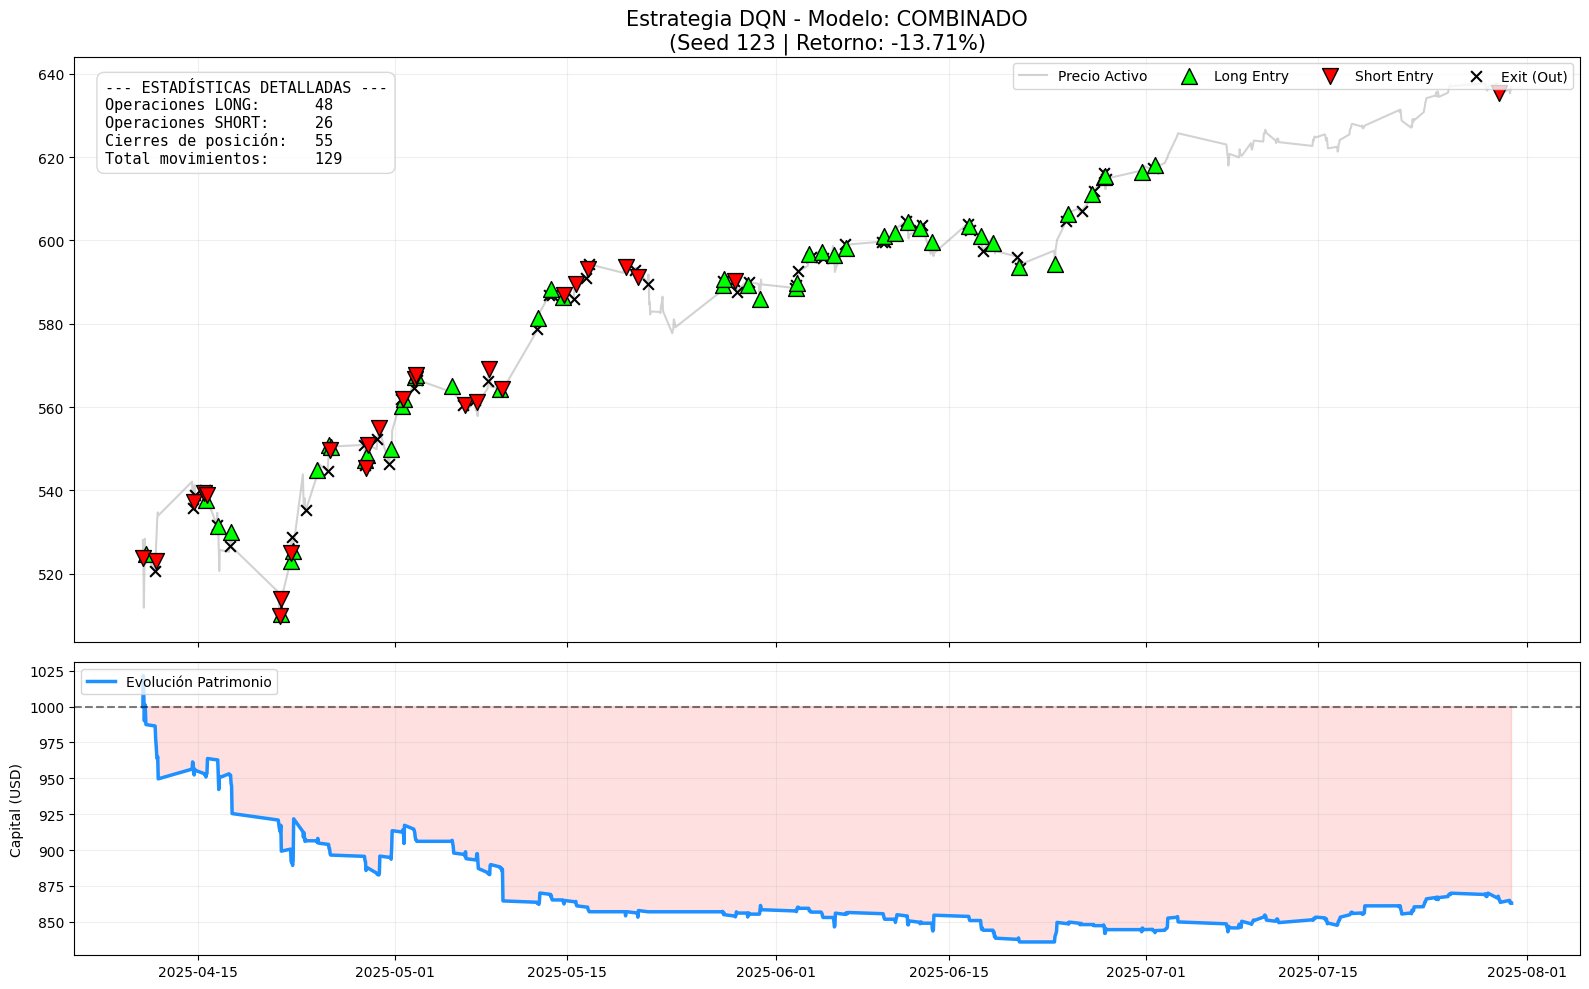


 📈 REPORTE VISUAL DQN: COMBINADO | SEED: 456
✅ Datos sincronizados: 527 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  34
📉 Operaciones SHORT: 33
✖️ Cierres de posición: 18
🔄 Total movimientos: 85
----------------------------------
💰 Capital Final: $1027.98
📈 Retorno IA:      2.80%
📉 Retorno Mercado: 20.58%
🏆 Alpha vs Buy&Hold: -17.78%


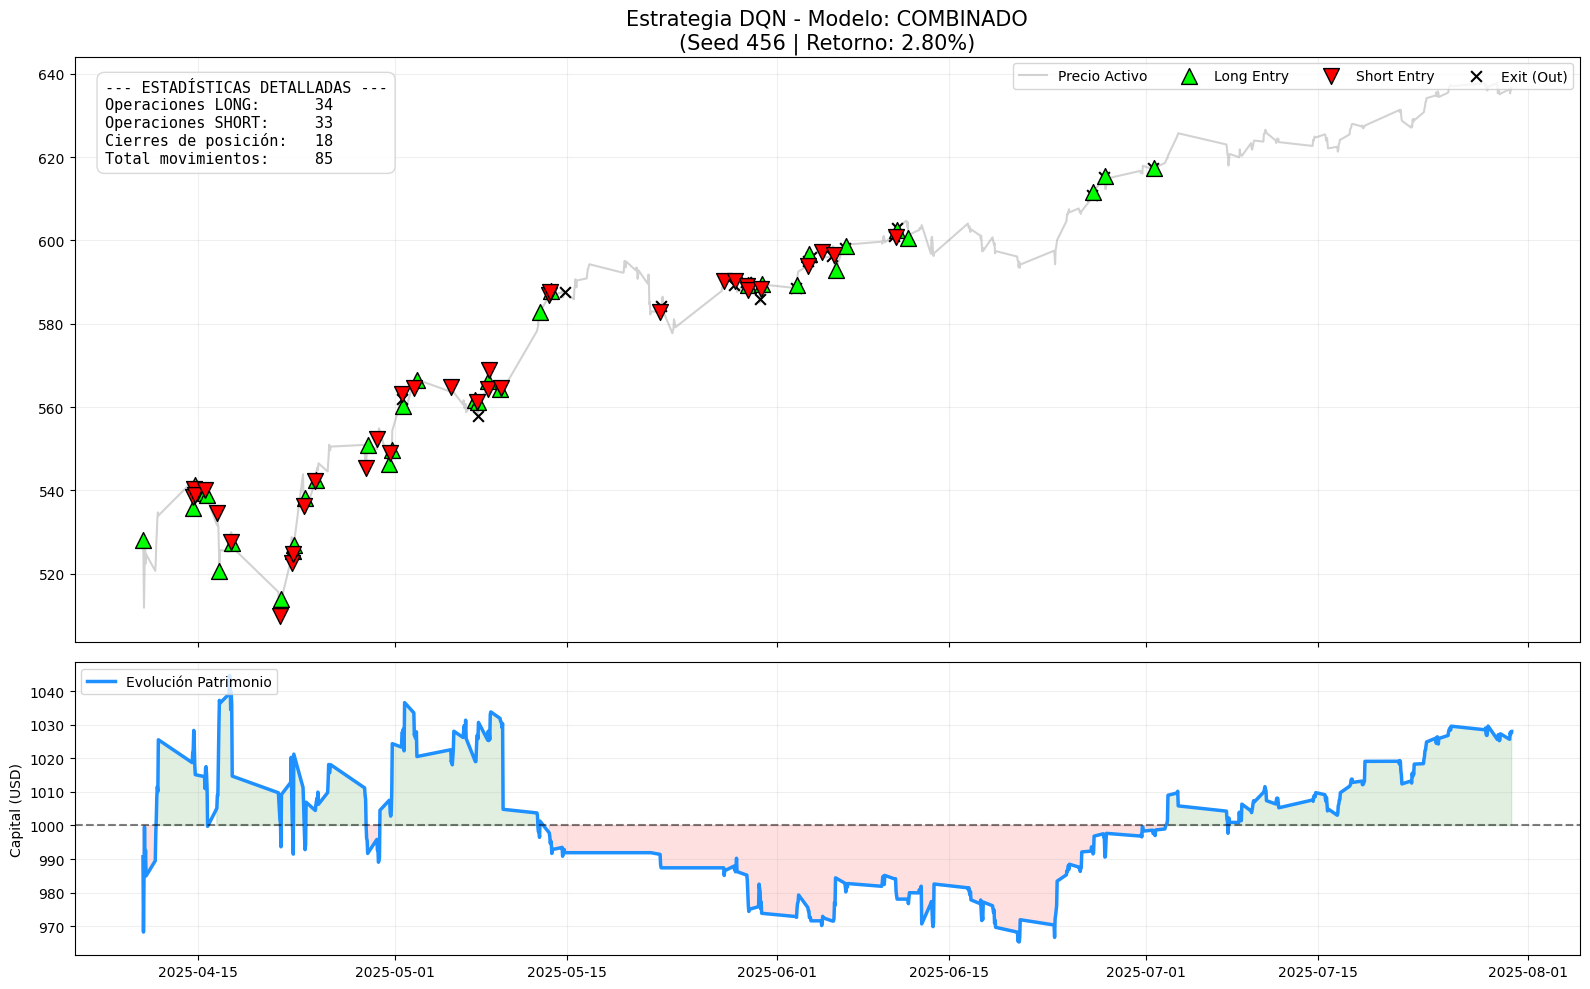


 📈 REPORTE VISUAL DQN: COMBINADO | SEED: 789
✅ Datos sincronizados: 527 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  42
📉 Operaciones SHORT: 31
✖️ Cierres de posición: 21
🔄 Total movimientos: 94
----------------------------------
💰 Capital Final: $950.36
📈 Retorno IA:      -4.96%
📉 Retorno Mercado: 20.58%
🏆 Alpha vs Buy&Hold: -25.54%


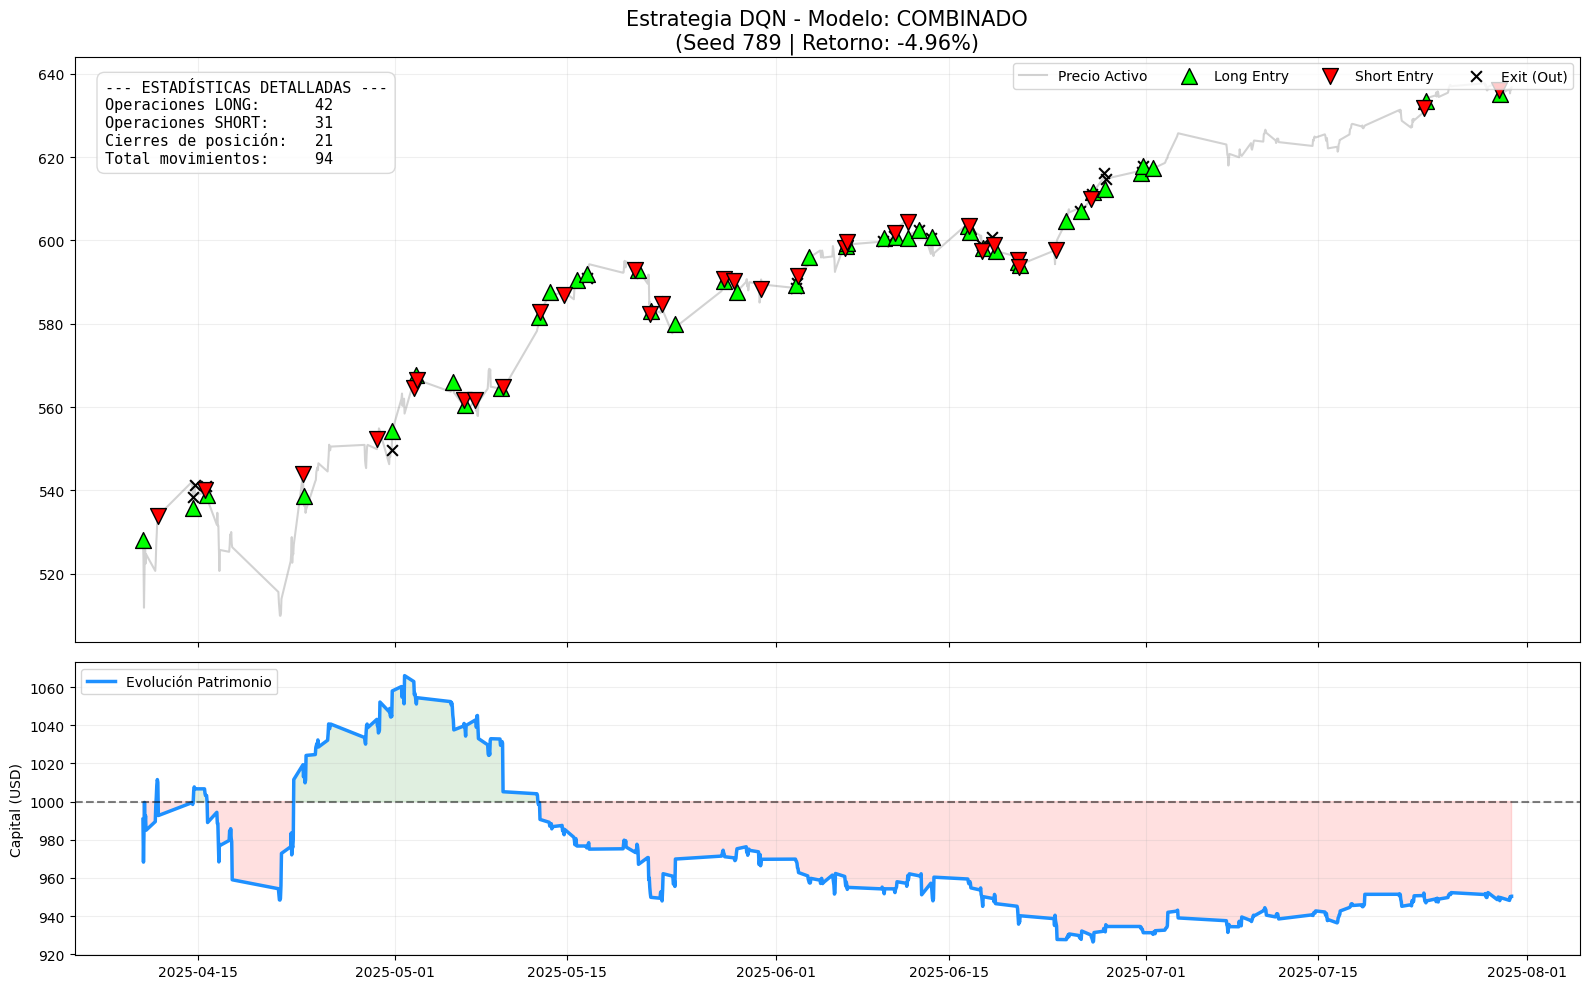


 📈 REPORTE VISUAL DQN: COMBINADO | SEED: 1011
✅ Datos sincronizados: 527 velas para test.

📊 --- ESTADÍSTICAS DETALLADAS ---
🚀 Operaciones LONG:  28
📉 Operaciones SHORT: 39
✖️ Cierres de posición: 45
🔄 Total movimientos: 112
----------------------------------
💰 Capital Final: $838.49
📈 Retorno IA:      -16.15%
📉 Retorno Mercado: 20.58%
🏆 Alpha vs Buy&Hold: -36.73%


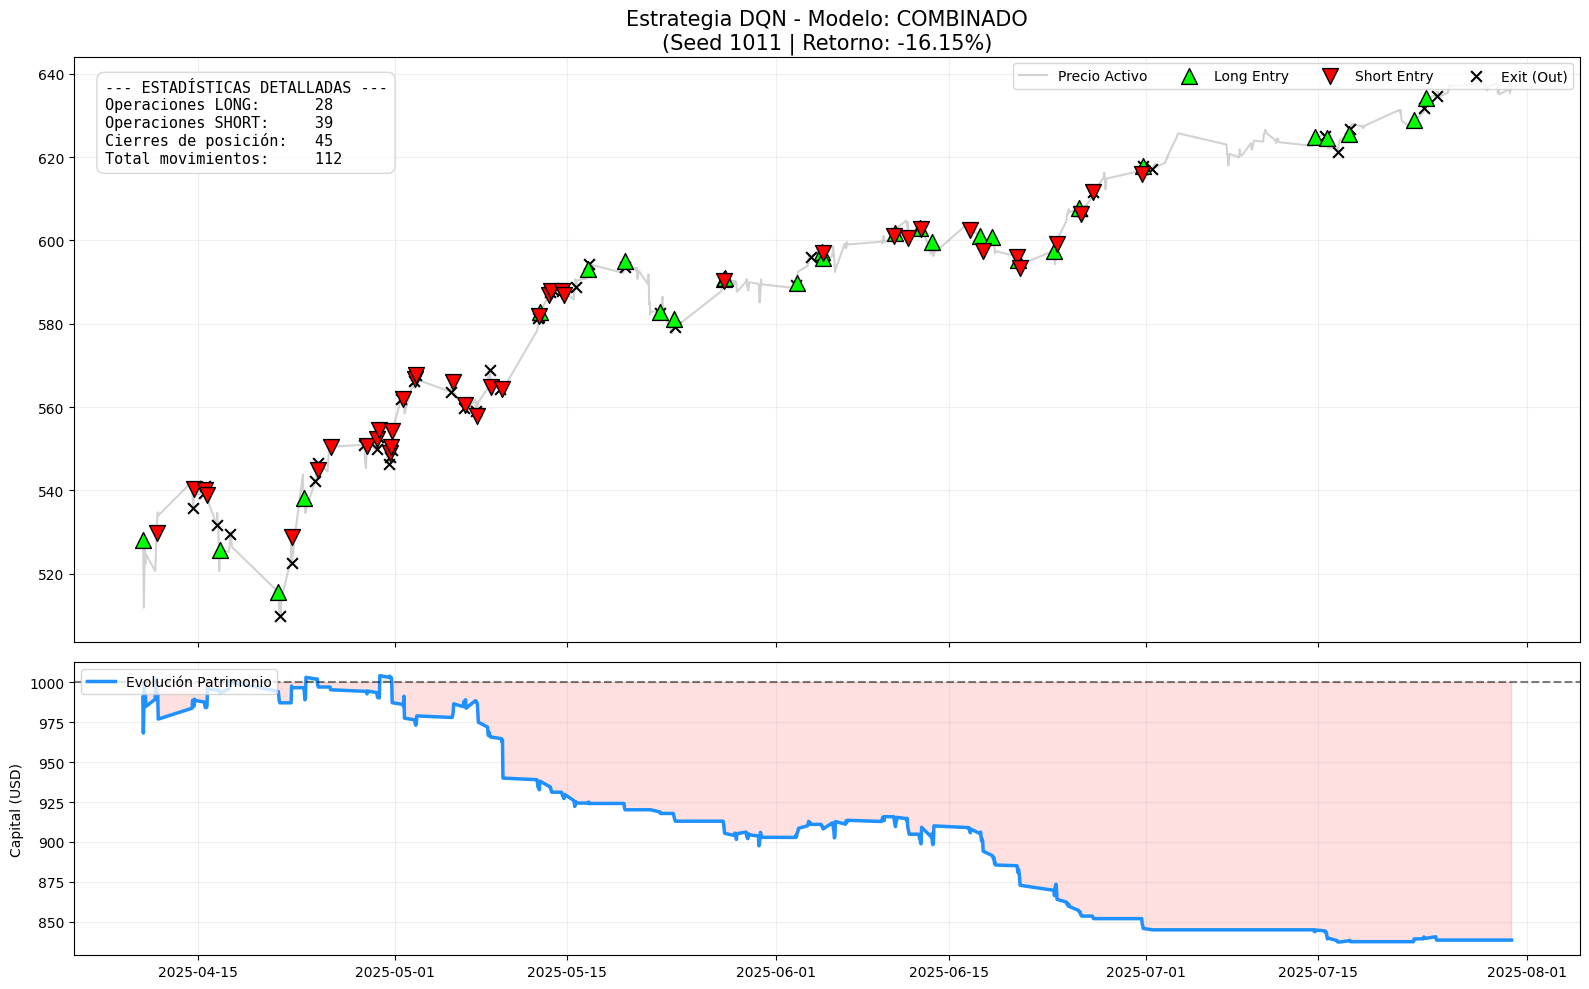

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from stable_baselines3 import DQN, PPO
from sklearn.preprocessing import MinMaxScaler

def plot_trading_results(model_name, seed, algorithm='dqn', tf="1h"):
    """
    Función integral para evaluar y graficar resultados de modelos RL.
    Sincroniza escalado, operativa de 3 estados (Short/Out/Long) y métricas.
    """
    print(f"\n" + "="*50)
    print(f" 📈 REPORTE VISUAL {algorithm.upper()}: {model_name.upper()} | SEED: {seed}")
    print("="*50)

    # 1. CARGA Y PREPARACIÓN DE DATOS (Sincronizado con Entrenamiento)
    try:
        df_feat, df_prices = load_data_all_types(model_name, tf)
        
        # Escalado Universal (Afecta a todos los modelos: Raw, AE, CPC, etc.)
        scaler = MinMaxScaler()
        train_mask = df_feat.index <= TRAIN_END_DATE
        df_feat = df_feat.ffill().bfill().fillna(0) # Limpieza de seguridad
        
        # Ajustamos el antes del escalador SOLO con los datos que el modelo vio en el entrenamiento
        scaler.fit(df_feat.loc[train_mask])
        df_feat_scaled = pd.DataFrame(
            scaler.transform(df_feat), 
            index=df_feat.index, 
            columns=df_feat.columns
        )
        
        # Split por fecha (no por tail) para asegurar que el punto de inicio es idéntico
        df_feat_val = df_feat_scaled[df_feat_scaled.index > TRAIN_END_DATE]
        df_prices_val = df_prices[df_prices.index > TRAIN_END_DATE]
        
        print(f"✅ Datos sincronizados: {len(df_feat_val)} velas para test.")
    except Exception as e:
        print(f"❌ Error en la carga de datos: {e}")
        return

    # 2. CARGA DEL AGENTE
    model_path = f"../RL_outputs/{foldername}/models/{algorithm}_{model_name}_seed_{seed}.zip"
    if not os.path.exists(model_path):
        print(f"❌ No se encuentra el modelo en: {model_path}")
        return
    
    # Seleccionamos clase según algoritmo
    AgentClass = DQN if algorithm == 'dqn' else PPO
    agent = AgentClass.load(model_path)

    # 3. SIMULACIÓN DE LA ESTRATEGIA
    init_bal = 1000 
    trade_fee = 0.001 
    
    env = SRLTradingEnv_v2(df_feat_val, df_prices_val, initial_balance=init_bal, fee=trade_fee, asset_type=foldername)
    obs, _ = env.reset()
    done = False
    
    net_worths = []
    prices_history = []
    dates = []
    
    # Listas para marcadores visuales
    long_entries = []
    short_entries = []
    exits = []
    
    # Contadores de operativa
    long_ops = 0
    short_ops = 0
    cierres = 0
    current_pos = 1 # 0:Short, 1:Out, 2:Long
    step = 0

    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        
        if action != current_pos:
            if action == 2: # Entra en Long
                long_entries.append(step)
                long_ops += 1
            elif action == 0: # Entra en Short
                short_entries.append(step)
                short_ops += 1
            elif action == 1: # Cierra posición a Out (Liquidez)
                exits.append(step)
                cierres += 1
            current_pos = action
            
        obs, reward, done, _, info = env.step(action)
        
        net_worths.append(info['net_worth'])
        prices_history.append(df_prices_val.iloc[step])
        dates.append(df_prices_val.index[step])
        step += 1

    # 4. CÁLCULO DE MÉTRICAS FINALES
    final_nw = net_worths[-1]
    retorno_total = ((final_nw / init_bal) - 1) * 100
    mercado_ret = ((prices_history[-1] / prices_history[0]) - 1) * 100
    total_movimientos = long_ops + short_ops + cierres

    print(f"\n📊 --- ESTADÍSTICAS DETALLADAS ---")
    print(f"🚀 Operaciones LONG:  {long_ops}")
    print(f"📉 Operaciones SHORT: {short_ops}")
    print(f"✖️ Cierres de posición: {cierres}")
    print(f"🔄 Total movimientos: {total_movimientos}")
    print("-" * 34)
    print(f"💰 Capital Final: ${final_nw:.2f}")
    print(f"📈 Retorno IA:      {retorno_total:.2f}%")
    print(f"📉 Retorno Mercado: {mercado_ret:.2f}%")
    print(f"🏆 Alpha vs Buy&Hold: {retorno_total - mercado_ret:.2f}%")
    print("="*50)

    # 5. GENERACIÓN DE GRÁFICAS
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [2, 1]})
    
    # --- SUBPLOT 1: PRECIO Y OPERACIONES ---
    ax1.plot(dates, prices_history, color='gray', alpha=0.35, label='Precio Activo')
    
    if long_entries:
        ax1.scatter([dates[i] for i in long_entries], [prices_history[i] for i in long_entries], 
                    marker='^', color='lime', s=130, label='Long Entry', edgecolors='black', zorder=5)
    if short_entries:
        ax1.scatter([dates[i] for i in short_entries], [prices_history[i] for i in short_entries], 
                    marker='v', color='red', s=130, label='Short Entry', edgecolors='black', zorder=5)
    if exits:
        ax1.scatter([dates[i] for i in exits], [prices_history[i] for i in exits], 
                    marker='x', color='black', s=60, label='Exit (Out)', zorder=4)
    
    ax1.set_title(f"Estrategia {algorithm.upper()} - Modelo: {model_name.upper()}\n(Seed {seed} | Retorno: {retorno_total:.2f}%)", fontsize=15)
    ax1.legend(loc='upper right', ncol=4) # Fijamos la leyenda arriba a la derecha para dejar libre la izquierda
    ax1.grid(alpha=0.2)

    # ==================== NUEVO: CUADRO DE ESTADÍSTICAS EN EL GRÁFICO ====================
    stats_text = (
        f"--- ESTADÍSTICAS DETALLADAS ---\n"
        f"Operaciones LONG:      {long_ops}\n"
        f"Operaciones SHORT:     {short_ops}\n"
        f"Cierres de posición:   {cierres}\n"
        f"Total movimientos:     {total_movimientos}"
    )
    
    # Insertamos el texto en la esquina superior izquierda (x=0.02, y=0.96) usando coordenadas del eje (0 a 1)
    ax1.text(0.02, 0.96, stats_text, transform=ax1.transAxes, fontsize=11,
             verticalalignment='top', horizontalalignment='left',
             fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='lightgray', alpha=0.85))
    # =====================================================================================

    # --- SUBPLOT 2: CURVA DE CAPITAL (EQUITY CURVE) ---
    ax2.plot(dates, net_worths, color='dodgerblue', lw=2.5, label='Evolución Patrimonio')
    ax2.axhline(y=init_bal, color='black', linestyle='--', alpha=0.5)
    
    nw_np = np.array(net_worths)
    ax2.fill_between(dates, init_bal, net_worths, where=(nw_np >= init_bal), color='green', alpha=0.12)
    ax2.fill_between(dates, init_bal, net_worths, where=(nw_np < init_bal), color='red', alpha=0.12)
    
    ax2.set_ylabel("Capital (USD)")
    ax2.legend(loc='upper left')
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()
# --- EJECUCIÓN ---

plot_trading_results('baseline', 42)
plot_trading_results('baseline', 123)
plot_trading_results('baseline', 456)
plot_trading_results('baseline', 789)
plot_trading_results('baseline', 1011)


plot_trading_results('temporal-ae', 42)
plot_trading_results('temporal-ae', 123)
plot_trading_results('temporal-ae', 456)
plot_trading_results('temporal-ae', 789)
plot_trading_results('temporal-ae', 1011)

plot_trading_results('cpc', 42)
plot_trading_results('cpc', 123)
plot_trading_results('cpc', 456)
plot_trading_results('cpc', 789)
plot_trading_results('cpc', 1011)

plot_trading_results('transformer', 42)
plot_trading_results('transformer', 123)
plot_trading_results('transformer', 456)
plot_trading_results('transformer', 789)
plot_trading_results('transformer', 1011)

plot_trading_results('combinado', 42)
plot_trading_results('combinado', 123)
plot_trading_results('combinado', 456)
plot_trading_results('combinado', 789)
plot_trading_results('combinado', 1011)



In [5]:
def trading_results(model_name, seed, tf="1h"):
    print(f"\n" + "="*50)
    print(f" ANALIZANDO MODELO: {model_name.upper()} | SEMILLA: {seed}")
    print("="*50)

    try:
        df_feat, df_prices = load_data_all_types(model_name, tf)
        
        # Escalado Universal
        scaler = MinMaxScaler()
        train_mask = df_feat.index <= TRAIN_END_DATE
        df_feat = df_feat.ffill().bfill().fillna(0) 
        
        scaler.fit(df_feat.loc[train_mask])
        df_feat_scaled = pd.DataFrame(
            scaler.transform(df_feat), 
            index=df_feat.index, 
            columns=df_feat.columns
        )
        
        # Split temporal idéntico al entrenamiento
        df_feat_val = df_feat_scaled[df_feat_scaled.index > TRAIN_END_DATE]
        df_prices_val = df_prices[df_prices.index > TRAIN_END_DATE]
        
    except Exception as e:
        print(f"❌ Error en preparación de datos: {e}")
        return

    model_path = f"../RL_outputs/{foldername}/models/dqn_{model_name}_seed_{seed}.zip"
    if not os.path.exists(model_path):
        print(f"❌ No se encuentra el archivo: {model_path}")
        return
    
    agent = DQN.load(model_path)
    env = SRLTradingEnv_v2(df_feat_val, df_prices_val, initial_balance=1000, fee=0.001,asset_type=foldername)
    
    obs, _ = env.reset()
    done = False
    net_worths = []
    
    # Contadores de operativa
    total_trades = 0
    compras = 0
    ventas = 0
    current_pos = 1 # Empezamos en OUT (1)

    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        
        # Si la acción cambia la posición actual
        if action != current_pos:
            total_trades += 1
            
            # Lógica: 0 (Short) < 1 (Out) < 2 (Long)
            if action > current_pos:
                # Estamos comprando (o para abrir Long o para cerrar Short)
                compras += 1
            else:
                # Estamos vendiendo (o para abrir Short o para cerrar Long)
                ventas += 1
                
            current_pos = action
            
        obs, reward, done, _, info = env.step(action)
        net_worths.append(info.get('net_worth'))

    final_nw = net_worths[-1]
    retorno_final = ((final_nw / 1000) - 1) * 100
    
    print(f"\n--- ESTADÍSTICAS DE OPERATIVA ---")
    print(f"🔵 Compras Totales: {compras}")
    print(f"🔴 Ventas Totales: {ventas}")
    print(f"📊 Total Cambios de Posición: {total_trades}")
    print(f"🏁 Balance Final: ${final_nw:.2f} | 📈 Retorno: {retorno_final:.2f}%")
    print("-" * 34)
    
    return retorno_final

In [6]:
# Configuración
MODELS = ['baseline', 'temporal-ae', 'cpc', 'transformer', 'combinado']
SEEDS = [42, 123, 456, 789, 1011]

# Diccionario para guardar todo
resultados_acumulados = {m: [] for m in MODELS}

print("🚀 Iniciando recolección de resultados para el informe...")

for m in MODELS:
    for s in SEEDS:
        # Ejecutamos la función y guardamos el retorno
        ret = trading_results(m, s, tf="1h")
        if ret is not None:
            resultados_acumulados[m].append(ret)

print("\n✅ Recolección finalizada.")

🚀 Iniciando recolección de resultados para el informe...

 ANALIZANDO MODELO: BASELINE | SEMILLA: 42

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras Totales: 29
🔴 Ventas Totales: 29
📊 Total Cambios de Posición: 58
🏁 Balance Final: $889.83 | 📈 Retorno: -11.02%
----------------------------------

 ANALIZANDO MODELO: BASELINE | SEMILLA: 123

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras Totales: 47
🔴 Ventas Totales: 45
📊 Total Cambios de Posición: 92
🏁 Balance Final: $812.20 | 📈 Retorno: -18.78%
----------------------------------

 ANALIZANDO MODELO: BASELINE | SEMILLA: 456

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras Totales: 46
🔴 Ventas Totales: 37
📊 Total Cambios de Posición: 83
🏁 Balance Final: $872.85 | 📈 Retorno: -12.71%
----------------------------------

 ANALIZANDO MODELO: BASELINE | SEMILLA: 789

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras Totales: 21
🔴 Ventas Totales: 22
📊 Total Cambios de Posición: 43
🏁 Balance Final: $986.05 | 📈 Retorno: -1.39%
----------------------------------



In [7]:
def generar_informe_completo(data):
    rows = []
    for modelo, retornos in data.items():
        if not retornos: continue
        
        media = np.mean(retornos)
        std = np.std(retornos)
        # Usamos LaTeX para la fórmula de consistencia en la memoria
        # Consistencia = $\frac{\mu}{\sigma}$
        consistencia = media / std if std > 1e-6 else (media if media > 0 else 0)
        
        rows.append({
            "Modelo": modelo.upper(),
            "Media_Num": media,
            "Desviacion_Num": std,
            "Consistencia_Num": consistencia
        })
    
    df_base = pd.DataFrame(rows)

    def preparar_tabla(df, col_sort, ascendente=False):
        temp = df.sort_values(by=col_sort, ascending=ascendente).copy()
        temp["Media (%)"] = temp["Media_Num"].map(lambda x: f"{x:.2f}%")
        temp["Desv. Std"] = temp["Desviacion_Num"].map(lambda x: f"{x:.2f}")
        temp["Consistencia"] = temp["Consistencia_Num"].map(lambda x: f"{x:.2f}")
        return temp[["Modelo", "Media (%)", "Desv. Std", "Consistencia"]]

    # Imprimir las tablas de clasificación
    sections = [
        ("RENTABILIDAD MEDIA (¿Quién gana más?)", "Media_Num", False),
        ("ESTABILIDAD / RIESGO (¿Quién es menos volátil?)", "Desviacion_Num", True),
        ("CONSISTENCIA (Ratio Media/Riesgo)", "Consistencia_Num", False)
    ]

    for titulo, col, asc in sections:
        print("\n" + "="*70)
        print(titulo)
        print("="*70)
        print(preparar_tabla(df_base, col, asc).to_string(index=False))

# ¡Y finalmente ejecutamos!
generar_informe_completo(resultados_acumulados)


RENTABILIDAD MEDIA (¿Quién gana más?)
     Modelo Media (%) Desv. Std Consistencia
TRANSFORMER    -0.03%     14.24        -0.00
TEMPORAL-AE    -4.74%      6.10        -0.78
  COMBINADO    -6.98%      7.01        -1.00
   BASELINE    -9.00%      6.84        -1.32
        CPC   -14.02%      7.49        -1.87

ESTABILIDAD / RIESGO (¿Quién es menos volátil?)
     Modelo Media (%) Desv. Std Consistencia
TEMPORAL-AE    -4.74%      6.10        -0.78
   BASELINE    -9.00%      6.84        -1.32
  COMBINADO    -6.98%      7.01        -1.00
        CPC   -14.02%      7.49        -1.87
TRANSFORMER    -0.03%     14.24        -0.00

CONSISTENCIA (Ratio Media/Riesgo)
     Modelo Media (%) Desv. Std Consistencia
TRANSFORMER    -0.03%     14.24        -0.00
TEMPORAL-AE    -4.74%      6.10        -0.78
  COMBINADO    -6.98%      7.01        -1.00
   BASELINE    -9.00%      6.84        -1.32
        CPC   -14.02%      7.49        -1.87


In [8]:
import os
import numpy as np
import pandas as pd
from stable_baselines3 import PPO
from sklearn.preprocessing import MinMaxScaler

# 1. Asegúrate de tener configuradas las mismas variables globales
# foldername = "ETH" (o la que corresponda a tu MODE actual)
print(f"Reconstruyendo resultados para el activo: {foldername}")

batch_results = []

# Iteramos exactamente por tus modelos y semillas
for model_name in MODELS_TO_TEST:
    try:
        # Cargamos los datos limpios mediante tu función original
        df_feat, df_prices = load_data_all_types(model_name, TIMEFRAME)
    except FileNotFoundError:
        print(f"⚠️ No se encontraron datos para {model_name}. Saltando...")
        continue

    # --- ESCALADO UNIVERSAL (Clonamos exactamente la lógica de tu entrenamiento) ---
    scaler = MinMaxScaler()
    train_mask = df_feat.index <= TRAIN_END_DATE
    df_feat = df_feat.ffill().bfill().fillna(0) 
    
    scaler.fit(df_feat.loc[train_mask])
    df_feat_scaled = pd.DataFrame(
        scaler.transform(df_feat), 
        index=df_feat.index, 
        columns=df_feat.columns
    )
    
    # Split temporal de validación/test
    df_feat_val = df_feat_scaled[df_feat_scaled.index > TRAIN_END_DATE]
    df_prices_val = df_prices[df_prices.index > TRAIN_END_DATE]

    for seed in SEEDS:
        model_path = f"../RL_outputs/{foldername}/models/dqn_{model_name}_seed_{seed}.zip"
        
        # Verificamos si el .zip real existe en tu disco
        if not os.path.exists(model_path):
            print(f"❌ Archivo no encontrado: {model_path}. No se procesará.")
            continue
            
        print(f"🔄 Evaluando {model_name.upper()} (Semilla {seed}) desde el archivo .zip...")
        
        # CARGAMOS EL AGENTE DIRECTAMENTE (Cero reentrenamiento)
        agent = DQN.load(model_path)
        
        # Creamos el entorno de test
        val_env = SRLTradingEnv_v2(
            df_feat_val, 
            df_prices_val, 
            initial_balance=INITIAL_BALANCE, 
            fee=FEE,
            asset_type=foldername
        )
        
        obs, _ = val_env.reset()
        done = False
        history = []

        # Simulación ultra rápida en el entorno de test (tarda menos de 1 segundo por modelo)
        while not done:
            action, _ = agent.predict(obs, deterministic=True)
            obs, reward, done, _, info = val_env.step(action)
            history.append(info['net_worth'])
        
        final_nw = history[-1]
        total_return = (final_nw - INITIAL_BALANCE) / INITIAL_BALANCE
        
        # Añadimos al lote tal cual lo hacías en el entrenamiento original
        batch_results.append({
            'srl_model': model_name,
            'seed': seed,
            'final_net_worth': final_nw,
            'total_return': total_return,
            'equity_curve': history
        })

print(f"\n✅ ¡Estructura `batch_results` reconstruida con éxito! Total de experimentos recuperados: {len(batch_results)}")

Reconstruyendo resultados para el activo: SP500
🔄 Evaluando BASELINE (Semilla 42) desde el archivo .zip...
🔄 Evaluando BASELINE (Semilla 123) desde el archivo .zip...
🔄 Evaluando BASELINE (Semilla 456) desde el archivo .zip...
🔄 Evaluando BASELINE (Semilla 789) desde el archivo .zip...
🔄 Evaluando BASELINE (Semilla 1011) desde el archivo .zip...
🔄 Evaluando TEMPORAL-AE (Semilla 42) desde el archivo .zip...
🔄 Evaluando TEMPORAL-AE (Semilla 123) desde el archivo .zip...
🔄 Evaluando TEMPORAL-AE (Semilla 456) desde el archivo .zip...
🔄 Evaluando TEMPORAL-AE (Semilla 789) desde el archivo .zip...
🔄 Evaluando TEMPORAL-AE (Semilla 1011) desde el archivo .zip...
🔄 Evaluando CPC (Semilla 42) desde el archivo .zip...
🔄 Evaluando CPC (Semilla 123) desde el archivo .zip...
🔄 Evaluando CPC (Semilla 456) desde el archivo .zip...
🔄 Evaluando CPC (Semilla 789) desde el archivo .zip...
🔄 Evaluando CPC (Semilla 1011) desde el archivo .zip...
🔄 Evaluando TRANSFORMER (Semilla 42) desde el archivo .zip...


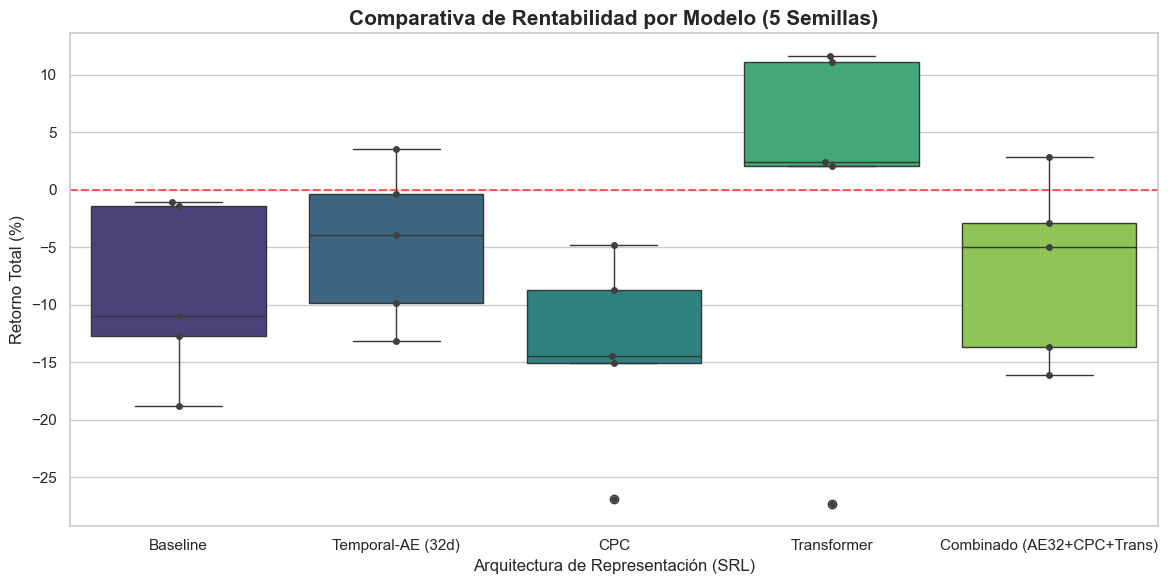

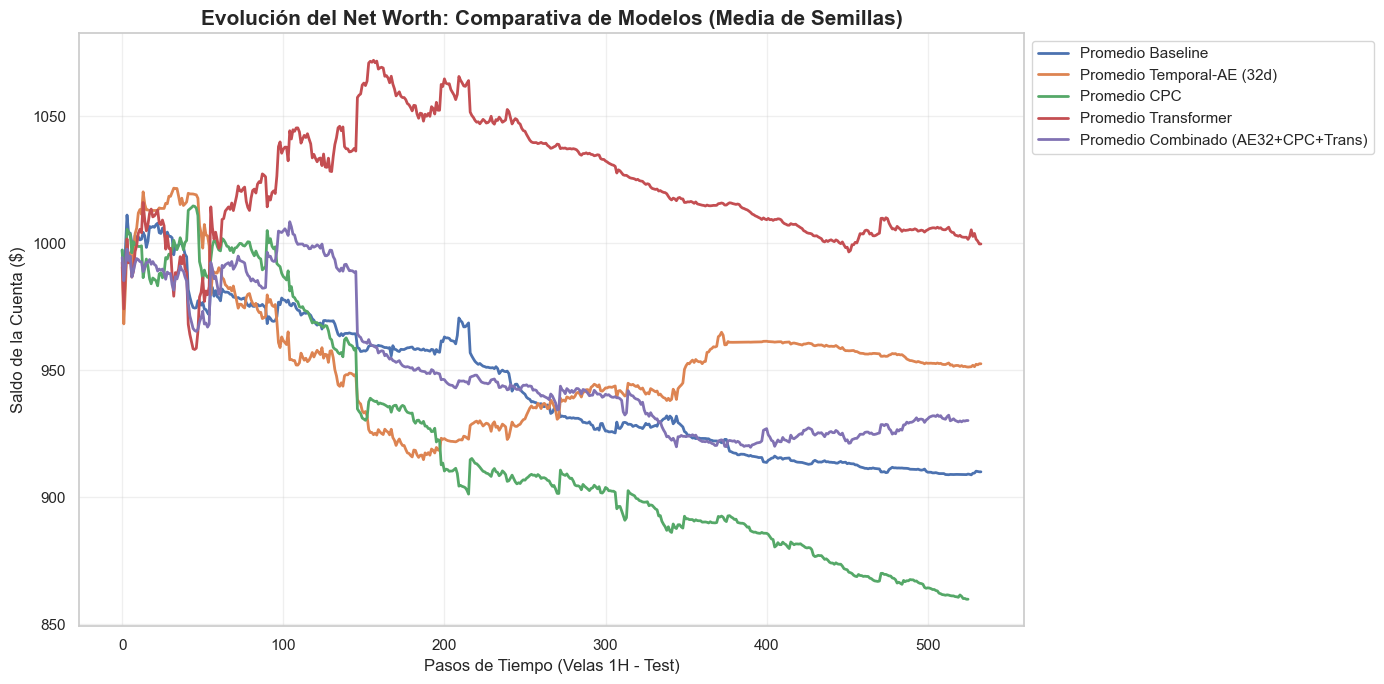

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def graficar_comparativa_tfg(batch_results):
    # 1. Preparar datos para el Boxplot
    df_results = pd.DataFrame(batch_results)
    # Convertir nombres a algo más bonito para el gráfico
    name_map = {
        'baseline': 'Baseline',
        'temporal-ae': 'Temporal-AE (32d)',
        'cpc': 'CPC',
        'transformer': 'Transformer',
        'combinado': 'Combinado (AE32+CPC+Trans)'
    }
    df_results['srl_model'] = df_results['srl_model'].map(name_map)
    df_results['return_pct'] = df_results['total_return'] * 100

    # Configuración de estilo
    sns.set_theme(style="whitegrid")
    plt.rcParams['figure.dpi'] = 100

    # --- GRÁFICA 1: BOXPLOT (Estabilidad y Retorno) ---
    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(x='srl_model', y='return_pct', data=df_results, 
                     palette="viridis", hue='srl_model', legend=False)
    sns.swarmplot(x='srl_model', y='return_pct', data=df_results, color=".25", size=5)
    
    plt.title('Comparativa de Rentabilidad por Modelo (5 Semillas)', fontsize=15, fontweight='bold')
    plt.ylabel('Retorno Total (%)', fontsize=12)
    plt.xlabel('Arquitectura de Representación (SRL)', fontsize=12)
    plt.axhline(0, color='red', linestyle='--', alpha=0.6) # Línea de 0 beneficio
    plt.tight_layout()
    plt.show()

    # --- GRÁFICA 2: EQUITY CURVES (Evolución del dinero) ---
    # Vamos a graficar la curva promedio de cada modelo para que no sea un caos de líneas
    plt.figure(figsize=(14, 7))
    
    for model in df_results['srl_model'].unique():
        # Filtramos por modelo
        model_data = df_results[df_results['srl_model'] == model]
        # Sacamos todas las curvas de equity (net worth)
        curves = np.array(model_data['equity_curve'].tolist())
        # Calculamos la media de las 5 semillas
        mean_curve = curves.mean(axis=0)
        
        plt.plot(mean_curve, label=f'Promedio {model}', linewidth=2)

    plt.title('Evolución del Net Worth: Comparativa de Modelos (Media de Semillas)', fontsize=15, fontweight='bold')
    plt.xlabel('Pasos de Tiempo (Velas 1H - Test)', fontsize=12)
    plt.ylabel('Saldo de la Cuenta ($)', fontsize=12)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Ejecutar:
graficar_comparativa_tfg(batch_results)

In [ ]:
def calcular_metricas_financieras(batch_results):
    df = pd.DataFrame(batch_results)
    
    # 1. Función para calcular Max Drawdown
    def get_max_drawdown(equity_curve):
        equity_curve = np.array(equity_curve)
        peak = np.maximum.accumulate(equity_curve)
        drawdown = (equity_curve - peak) / peak
        return drawdown.min() * 100

    df['max_drawdown'] = df['equity_curve'].apply(get_max_drawdown)
    df['return_pct'] = df['total_return'] * 100

    # --- GRÁFICA: RETORNO VS RIESGO (SCATTER PLOT) ---
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='max_drawdown', y='return_pct', hue='srl_model', style='srl_model', s=100)
    
    plt.title('Eficiencia: Retorno vs Máximo Drawdown', fontsize=14)
    plt.xlabel('Máximo Drawdown (%) - ¡Más a la derecha es mejor!', fontsize=12)
    plt.ylabel('Retorno Total (%)', fontsize=12)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # --- TABLA RESUMEN PARA TU MEMORIA ---
    resumen = df.groupby('srl_model').agg({
        'return_pct': ['mean', 'std'],
        'max_drawdown': ['mean', 'min']
    }).round(2)
    
    print("\n📊 RESUMEN DE RIESGO-RECOMPENSA:")
    print(resumen)
    return resumen

# Ejecutar
resumen_tfg = calcular_metricas_financieras(batch_results)